# Aβ39 Monomer Analysis: Wild-Type vs G25D Mutant

**Molecular Dynamics Simulation Study**

Comparative analysis of the structural and dynamical properties of the 39-residue Amyloid-β peptide (Aβ39) in its wild-type form and the G25D mutant.

### Systems
- **WT** — Wild-Type Aβ39  
- **G25D** — Glycine 25 → Aspartic acid mutant

### Simulation Details
- **Force field**: CHARMM36m  
- **Water model**: TIP3P  
- **Temperature**: 310 K  
- **Trajectory length**: 160 ns (PBC-corrected, protein-only)  
- **Analysis tools**: MDAnalysis, NumPy, Matplotlib, SciPy

### Analyzed Properties
- RMSD and RMSF  
- Radius of gyration (Rg) and end-to-end distance  
- Secondary structure (DSSP)  
- Intramolecular hydrogen bonds  
- Key salt bridges (D23–K28, E22–K28)  
- Residue contact maps  
- Central Hydrophobic Cluster (CHC) compactness  
- Principal Component Analysis (PCA)  
- Convergence diagnostics (block averaging, KS test, autocorrelation)

This notebook provides a comprehensive structural comparison between the wild-type and mutant Aβ39 monomers.

# 0. Imports and cosmetic options

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.signal import correlate

import MDAnalysis as mda
from MDAnalysis.analysis import rms, align, distances, pca
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA

# Publication-quality plot settings
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.linewidth": 0.8,
    "axes.labelsize": 11,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "legend.frameon": False,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight"
})

print(f"MDAnalysis version: {mda.__version__}")

MDAnalysis version: 2.10.0


In [2]:
# Plot styling
colors = {"WT": "magenta", "G25D": "cyan"}
labels = {"WT": "Wild-Type", "G25D": "G25D mutant"}

plt.rcParams['figure.facecolor'] = 'black'
plt.rcParams['axes.facecolor'] = 'black'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['legend.facecolor'] = 'black'
plt.rcParams['legend.edgecolor'] = 'white'
plt.rcParams['grid.color'] = 'gray'

## 1. Load trajectories

In [3]:
TPR_WT = "../XTCs_and_TPRs/NO_SOL/protein_only_solo_WT.tpr"
XTC_WT = "../XTCs_and_TPRs/NO_SOL/protein_only_solo_WT.xtc"
TPR_G25D = "../XTCs_and_TPRs/NO_SOL/protein_only_solo_G25D.tpr"
XTC_G25D = "../XTCs_and_TPRs/NO_SOL/protein_only_solo_G25D.xtc"

u_WT = mda.Universe(TPR_WT, XTC_WT)
u_G25D = mda.Universe(TPR_G25D, XTC_G25D)

protein_WT = u_WT.select_atoms("protein")
protein_G25D = u_G25D.select_atoms("protein")
ca_WT = u_WT.select_atoms("protein and name CA")
ca_G25D = u_G25D.select_atoms("protein and name CA")

n_frames = u_WT.trajectory.n_frames
dt_ps = u_WT.trajectory.dt
total_ns = u_WT.trajectory.totaltime / 1000

print(f"Frames: {n_frames} | dt = {dt_ps} ps | Total time: {total_ns:.1f} ns")
print(f"WT:    {ca_WT.n_residues} residues, {len(protein_WT)} atoms")
print(f"G25D:  {ca_G25D.n_residues} residues, {len(protein_G25D)} atoms")

time_ns = np.arange(n_frames) * dt_ps / 1000
resids = ca_WT.resids

Frames: 16001 | dt = 10.0 ps | Total time: 160.0 ns
WT:    39 residues, 582 atoms
G25D:  39 residues, 587 atoms


## 1b. Align trajectories

In [4]:
def align_trajectory(u, tpr):
    ref = mda.Universe(tpr, u.trajectory.filename)
    ref.trajectory[0]
    aligner = align.AlignTraj(u, ref, select="protein and name CA", in_memory=True)
    aligner.run()
    return u

print("Aligning trajectories to first frame (Cα)...")
u_WT = align_trajectory(u_WT, TPR_WT)
u_G25D = align_trajectory(u_G25D, TPR_G25D)
print("✅ Both trajectories aligned")

Aligning trajectories to first frame (Cα)...
✅ Both trajectories aligned


## 2. RMSD analysis

/home/sergey_ilin/anaconda3/envs/ml-hw5/lib/python3.11/site-packages/MDAnalysis/analysis/rms.py:824: DeprecationWarning: The `rmsd` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.rmsd` instead.
  warnings.warn(wmsg, DeprecationWarning)


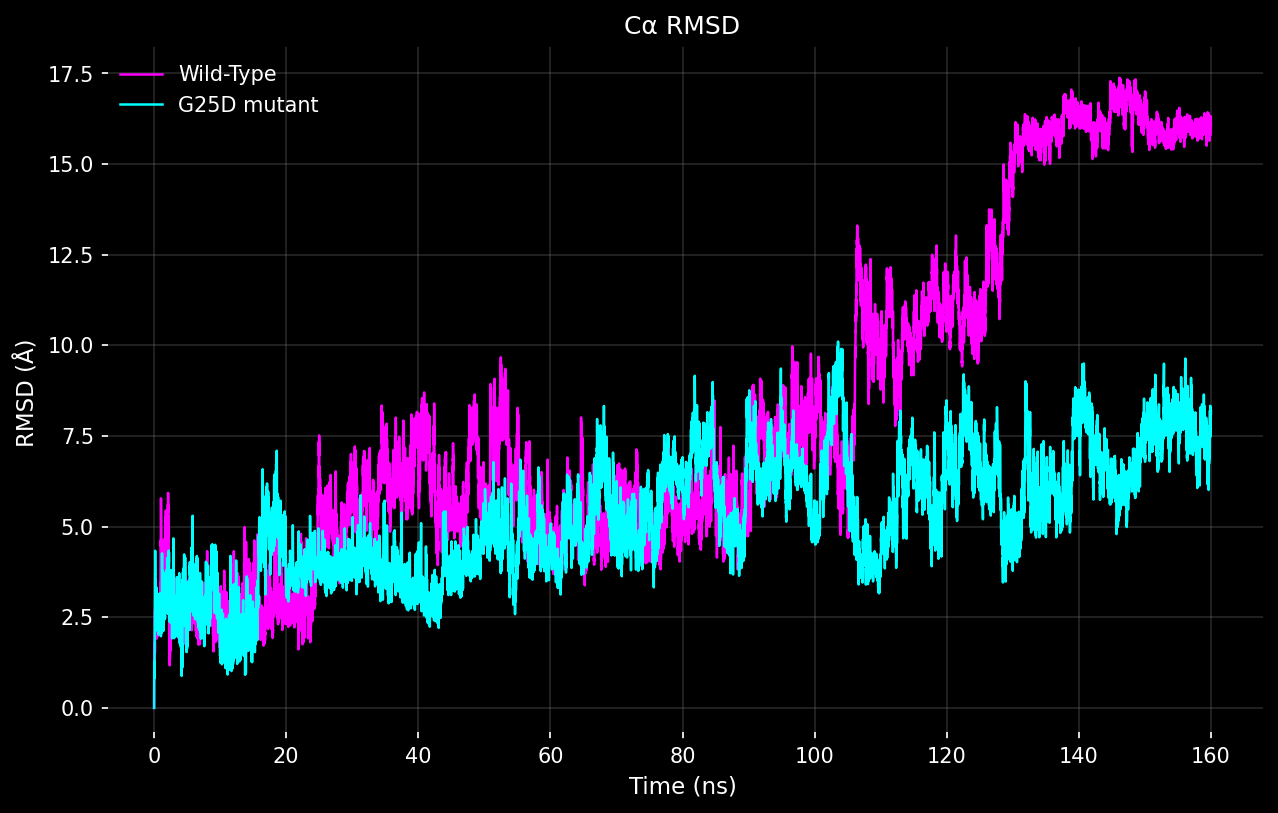

In [5]:
rmsd_WT = rms.RMSD(u_WT, select="protein and name CA").run()
rmsd_G25D = rms.RMSD(u_G25D, select="protein and name CA").run()

plt.figure(figsize=(10, 6))
plt.plot(time_ns, rmsd_WT.rmsd[:, 2], label=labels["WT"], color=colors["WT"], lw=1.2)
plt.plot(time_ns, rmsd_G25D.rmsd[:, 2], label=labels["G25D"], color=colors["G25D"], lw=1.2)
plt.xlabel("Time (ns)")
plt.ylabel("RMSD (Å)")
plt.title("Cα RMSD")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

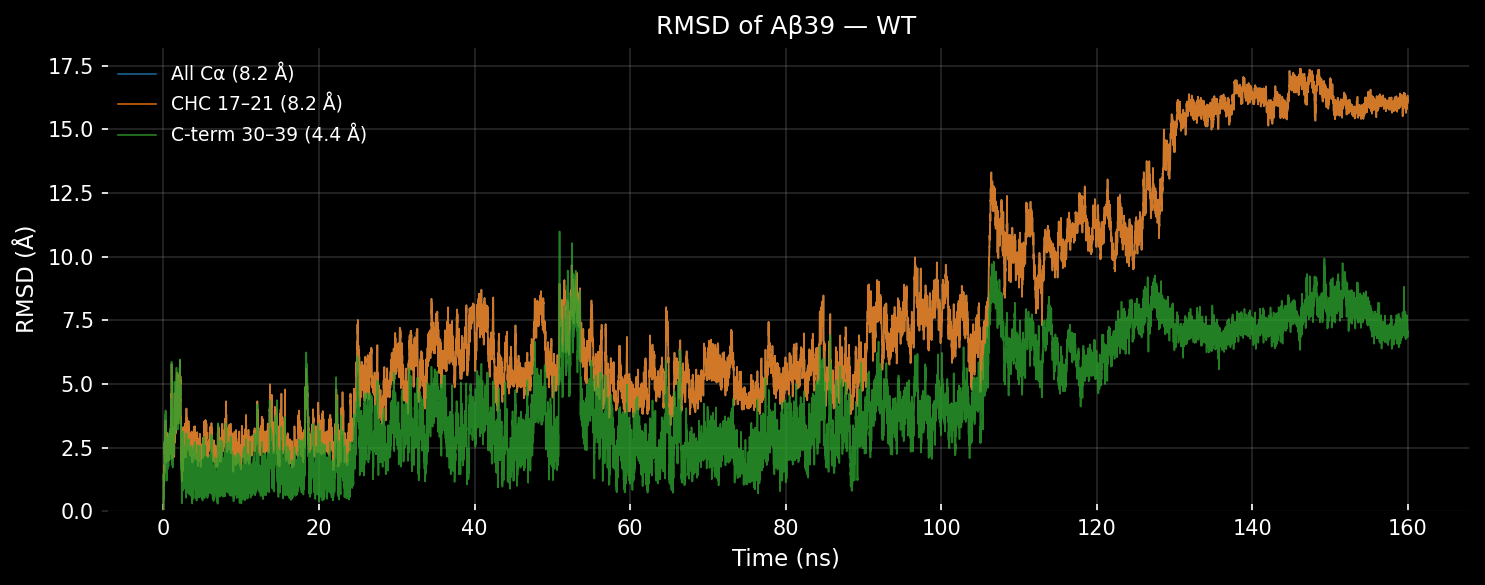

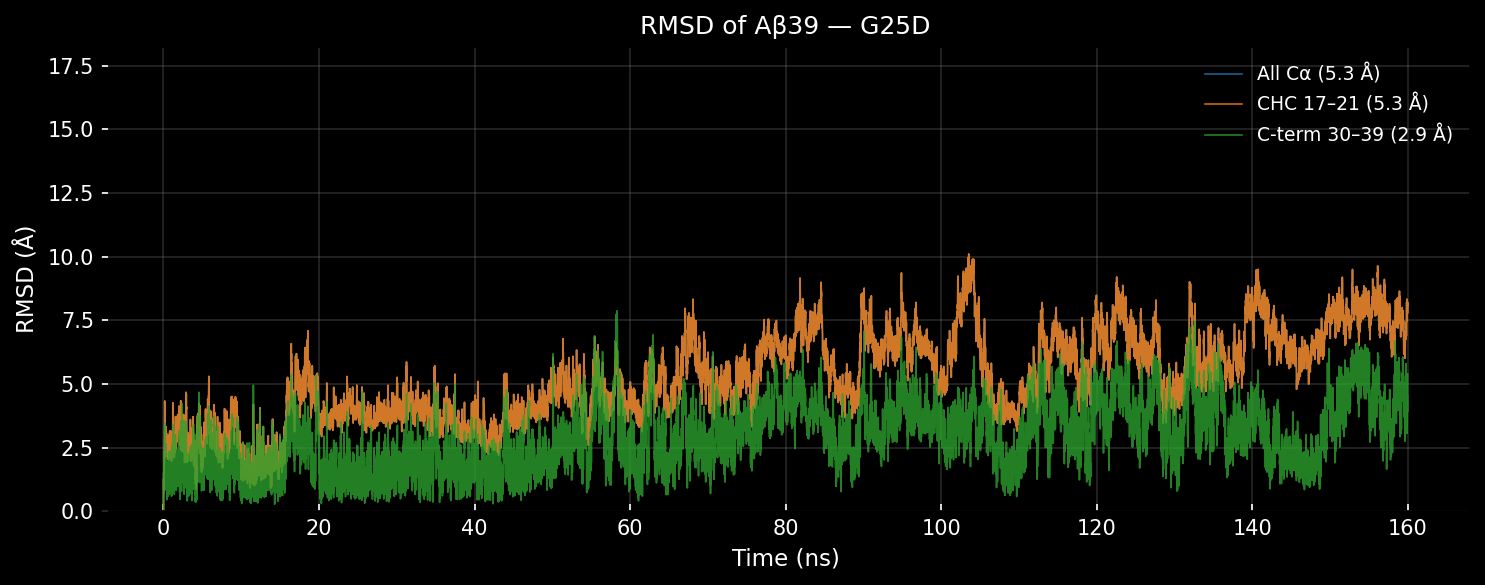

In [6]:
def compute_rmsd(u, label, tpr_file):
    ref = mda.Universe(tpr_file, u.trajectory.filename)
    ref.trajectory[0]

    R = rms.RMSD(u, ref,
                 select="protein and name CA",
                 groupselections=[
                     "protein and name CA",         # all Cα
                     "resid 17:21 and name CA",     # CHC (LVFFA)
                     "resid 30:39 and name CA",     # C-terminal
                 ])
    R.run()

    time_ns = R.results.rmsd[:, 1] / 1000
    rmsd_all = R.results.rmsd[:, 2]
    rmsd_chc = R.results.rmsd[:, 3]
    rmsd_cterm = R.results.rmsd[:, 4]

    return time_ns, rmsd_all, rmsd_chc, rmsd_cterm, label


results = {}
for u, tpr, name in [(u_WT, TPR_WT, "WT"), (u_G25D, TPR_G25D, "G25D")]:
    time, all_r, chc_r, cterm_r, lbl = compute_rmsd(u, name, tpr)
    results[name] = {
        "time": time,
        "all": all_r,
        "chc": chc_r,
        "cterm": cterm_r,
        "label": lbl
    }


all_values = []
for name in results:
    all_values.extend(results[name]["all"])
    all_values.extend(results[name]["chc"])
    all_values.extend(results[name]["cterm"])

y_min = 0
y_max = max(all_values) * 1.05


def plot_rmsd(data, title, ylim, outfile):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(data["time"], data["all"], lw=0.8, alpha=0.8,
            label=f"All Cα ({data['all'].mean():.1f} Å)")
    ax.plot(data["time"], data["chc"], lw=0.8, alpha=0.8,
            label=f"CHC 17–21 ({data['chc'].mean():.1f} Å)")
    ax.plot(data["time"], data["cterm"], lw=0.8, alpha=0.8,
            label=f"C-term 30–39 ({data['cterm'].mean():.1f} Å)")
    ax.set_xlabel("Time (ns)")
    ax.set_ylabel("RMSD (Å)")
    ax.set_title(f"RMSD of Aβ39 — {title}")
    ax.set_ylim(ylim)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'../../images/{outfile}', dpi=300)
    plt.show()


plot_rmsd(results["WT"],   "WT",   (y_min, y_max), "rmsd_WT.png")
plot_rmsd(results["G25D"], "G25D", (y_min, y_max), "rmsd_G25D.png")

## 3. Radius of gyration (Rg)

Computing Radius of Gyration...
⟨Rg⟩ WT   = 1.505 ± 0.259 nm
⟨Rg⟩ G25D = 1.616 ± 0.121 nm


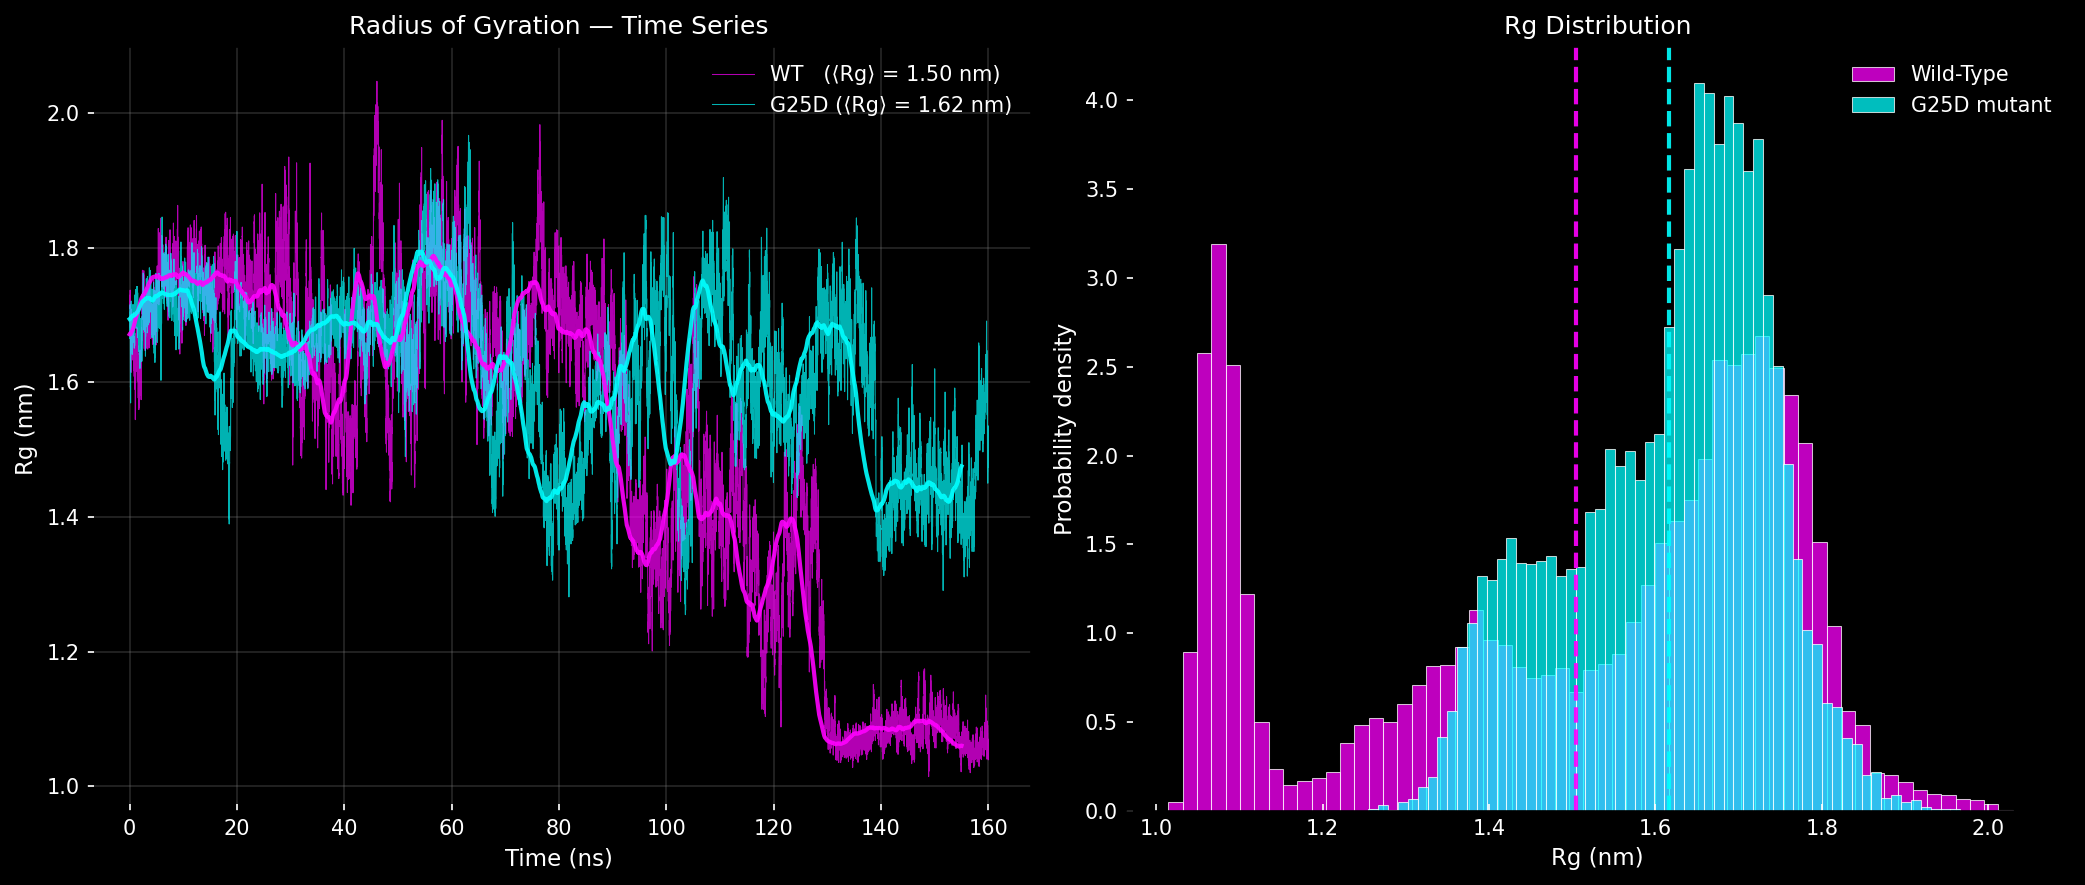

In [7]:
def compute_rg(u, protein):
    rg_A = np.zeros(u.trajectory.n_frames)
    for i, ts in enumerate(u.trajectory):
        rg_A[i] = protein.radius_of_gyration()
    return rg_A / 10.0  # Å → nm


print("Computing Radius of Gyration...")
rg_WT = compute_rg(u_WT, protein_WT)
rg_G25D = compute_rg(u_G25D, protein_G25D)

print(f"⟨Rg⟩ WT   = {rg_WT.mean():.3f} ± {rg_WT.std():.3f} nm")
print(f"⟨Rg⟩ G25D = {rg_G25D.mean():.3f} ± {rg_G25D.std():.3f} nm")


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Time series
ax = axes[0]
ax.plot(time_ns, rg_WT, lw=0.5, alpha=0.7, color=colors["WT"],
        label=f"WT   (⟨Rg⟩ = {rg_WT.mean():.2f} nm)")
ax.plot(time_ns, rg_G25D, lw=0.5, alpha=0.7, color=colors["G25D"],
        label=f"G25D (⟨Rg⟩ = {rg_G25D.mean():.2f} nm)")

w = min(500, n_frames // 5)
if w > 1:
    avg_WT = np.convolve(rg_WT, np.ones(w)/w, mode='valid')
    avg_G25D = np.convolve(rg_G25D, np.ones(w)/w, mode='valid')
    ax.plot(time_ns[:len(avg_WT)], avg_WT, lw=2.0, color=colors["WT"], alpha=0.9)
    ax.plot(time_ns[:len(avg_G25D)], avg_G25D, lw=2.0, color=colors["G25D"], alpha=0.9)

ax.set_xlabel("Time (ns)")
ax.set_ylabel("Rg (nm)")
ax.set_title("Radius of Gyration — Time Series")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Distributions
ax = axes[1]
ax.hist(rg_WT, bins=60, density=True, alpha=0.75, color=colors["WT"],
        label=labels["WT"], edgecolor="white", linewidth=0.5)
ax.hist(rg_G25D, bins=60, density=True, alpha=0.75, color=colors["G25D"],
        label=labels["G25D"], edgecolor="white", linewidth=0.5)

ax.axvline(rg_WT.mean(), color=colors["WT"], ls="--", lw=2, alpha=0.9)
ax.axvline(rg_G25D.mean(), color=colors["G25D"], ls="--", lw=2, alpha=0.9)

ax.set_xlabel("Rg (nm)")
ax.set_ylabel("Probability density")
ax.set_title("Rg Distribution")
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("../../images/03_rg_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Rg vs Ree (End-to-End Distance) scatter plot

Computing End-to-End distance...


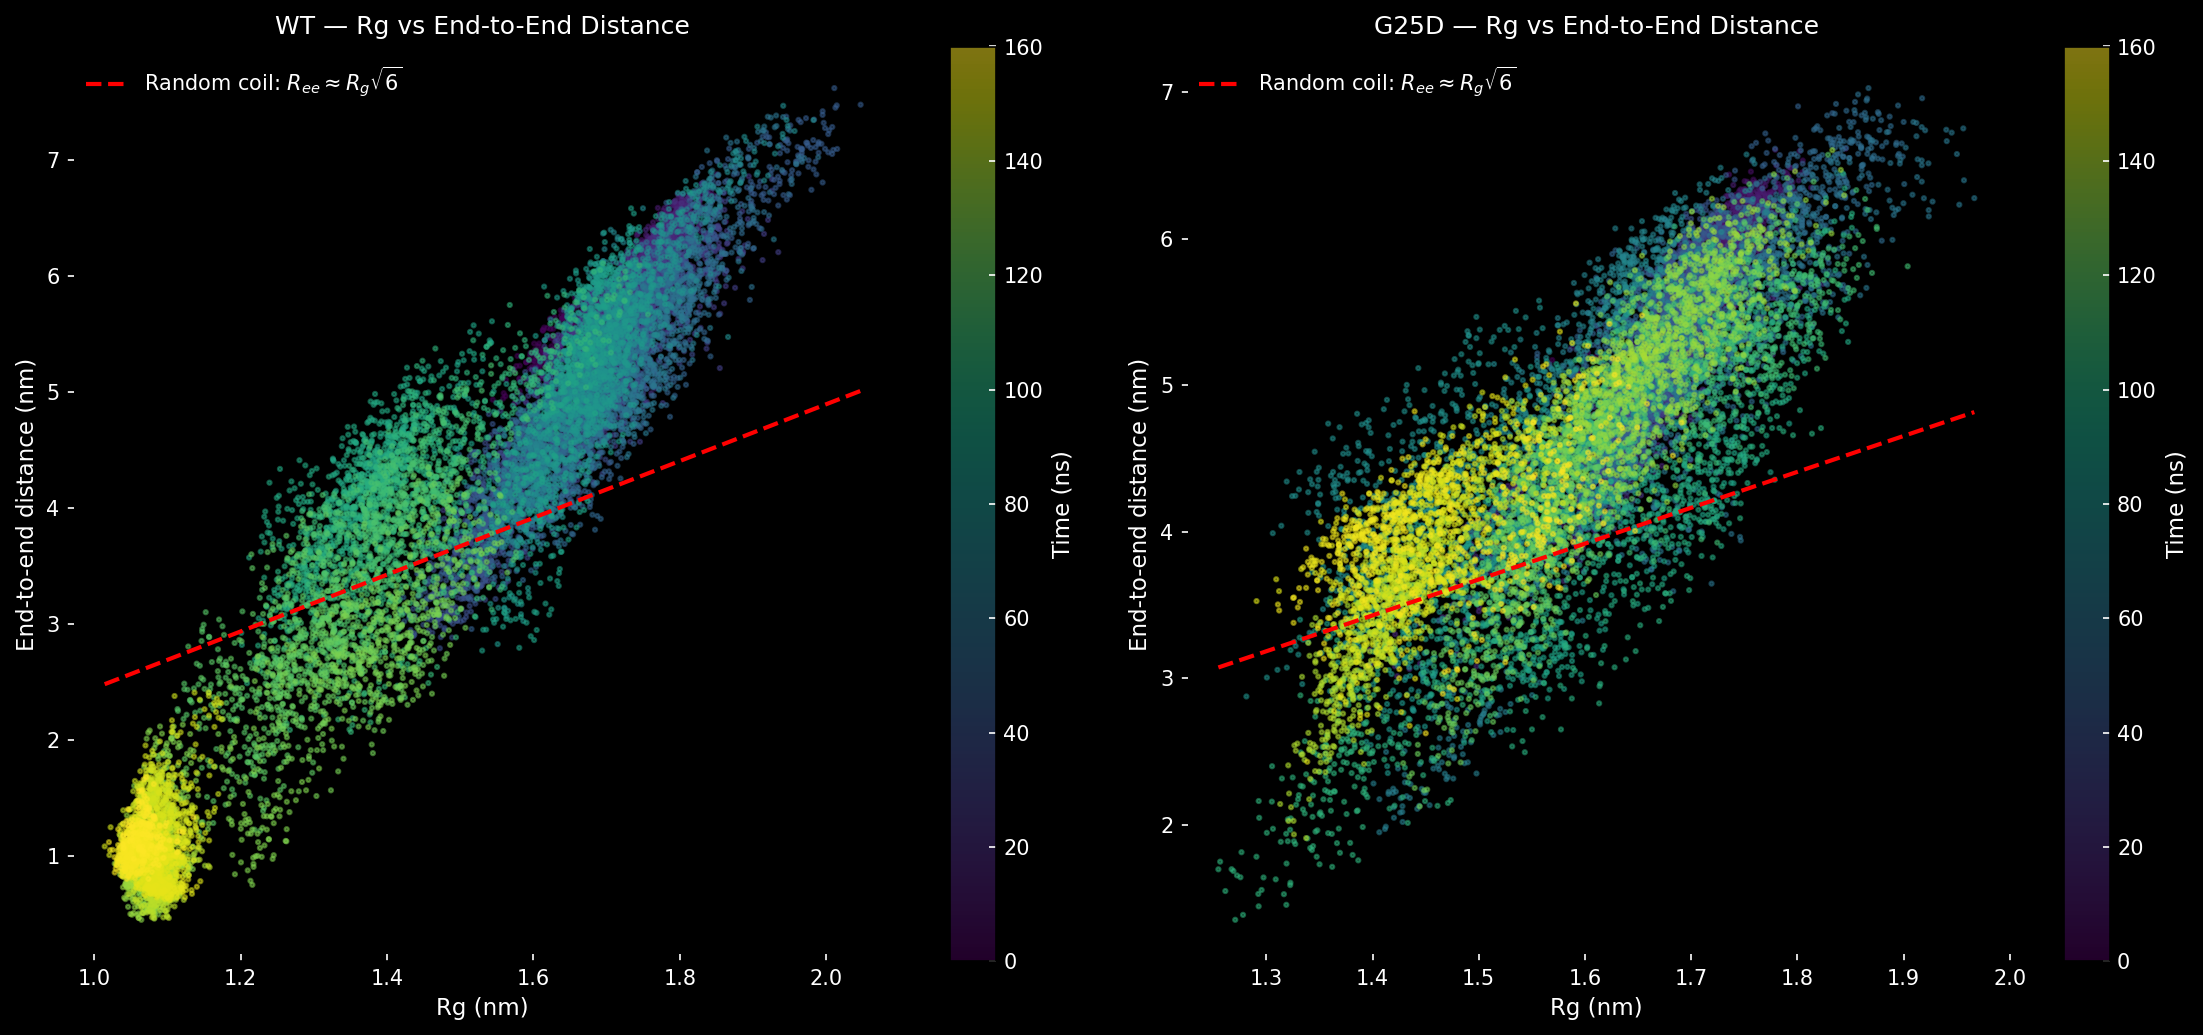

Pearson correlation Rg–Ree:
   WT:   r = 0.960 (p = 0.00e+00)
   G25D: r = 0.844 (p = 0.00e+00)


In [8]:
# End-to-End Distance (N-term CA ↔ C-term CA)

def compute_ree(u, ca_atoms):
    n_term_ca = u.select_atoms("resid 1 and name CA")
    c_term_ca = u.select_atoms(f"resid {ca_atoms.n_residues} and name CA")
    
    ree_values = np.empty(u.trajectory.n_frames)
    for i, ts in enumerate(u.trajectory):
        ree_values[i] = np.linalg.norm(
            n_term_ca.positions[0] - c_term_ca.positions[0]
        )
    return ree_values / 10.0  # Å → nm


print("Computing End-to-End distance...")

ree_WT   = compute_ree(u_WT,   ca_WT)
ree_G25D = compute_ree(u_G25D, ca_G25D)


# Rg vs Ree scatter plot

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# WT
sc1 = axes[0].scatter(rg_WT, ree_WT, c=time_ns, cmap="viridis", s=4, alpha=0.5)
axes[0].plot(np.linspace(rg_WT.min(), rg_WT.max(), 50),
             np.linspace(rg_WT.min(), rg_WT.max(), 50) * np.sqrt(6),
             "r--", lw=2, label=r"Random coil: $R_{ee} \approx R_g \sqrt{6}$")
axes[0].set_xlabel("Rg (nm)")
axes[0].set_ylabel("End-to-end distance (nm)")
axes[0].set_title("WT — Rg vs End-to-End Distance")
plt.colorbar(sc1, ax=axes[0], label="Time (ns)")
axes[0].legend()

# G25D
sc2 = axes[1].scatter(rg_G25D, ree_G25D, c=time_ns, cmap="viridis", s=4, alpha=0.5)
axes[1].plot(np.linspace(rg_G25D.min(), rg_G25D.max(), 50),
             np.linspace(rg_G25D.min(), rg_G25D.max(), 50) * np.sqrt(6),
             "r--", lw=2, label=r"Random coil: $R_{ee} \approx R_g \sqrt{6}$")
axes[1].set_xlabel("Rg (nm)")
axes[1].set_ylabel("End-to-end distance (nm)")
axes[1].set_title("G25D — Rg vs End-to-End Distance")
plt.colorbar(sc2, ax=axes[1], label="Time (ns)")
axes[1].legend()

plt.tight_layout()
plt.savefig("../../images/03_rg_vs_ree_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


# Correlation
r_WT,   p_WT   = stats.pearsonr(rg_WT,   ree_WT)
r_G25D, p_G25D = stats.pearsonr(rg_G25D, ree_G25D)

print(f"Pearson correlation Rg–Ree:")
print(f"   WT:   r = {r_WT:.3f} (p = {p_WT:.2e})")
print(f"   G25D: r = {r_G25D:.3f} (p = {p_G25D:.2e})")

## 5. RMSF

Computing RMSF...
Mean RMSF WT   = 7.09 Å
Mean RMSF G25D = 4.39 Å


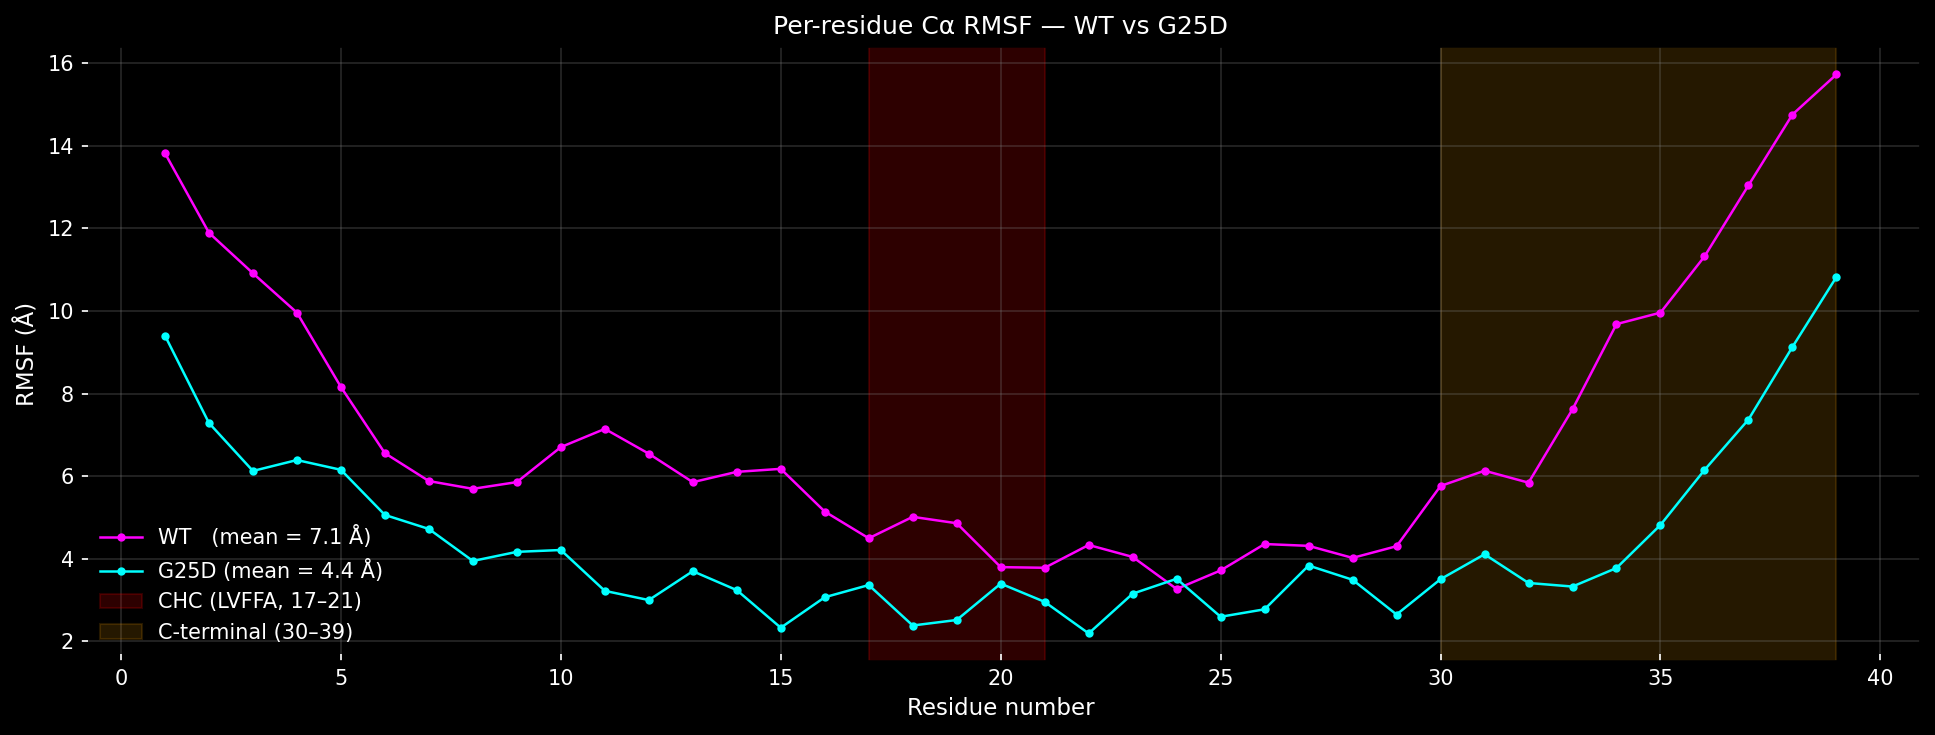

In [9]:
def compute_rmsf(u, ca_atoms):
    rmsf_calc = rms.RMSF(ca_atoms).run()
    return rmsf_calc.results.rmsf  # in Å


print("Computing RMSF...")

rmsf_WT   = compute_rmsf(u_WT,   ca_WT)
rmsf_G25D = compute_rmsf(u_G25D, ca_G25D)

print(f"Mean RMSF WT   = {rmsf_WT.mean():.2f} Å")
print(f"Mean RMSF G25D = {rmsf_G25D.mean():.2f} Å")


fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(resids, rmsf_WT,   "o-", color=colors["WT"],   markersize=3, lw=1.2,
        label=f"WT   (mean = {rmsf_WT.mean():.1f} Å)")
ax.plot(resids, rmsf_G25D, "o-", color=colors["G25D"], markersize=3, lw=1.2,
        label=f"G25D (mean = {rmsf_G25D.mean():.1f} Å)")

ax.axvspan(17, 21, alpha=0.18, color="red",    label="CHC (LVFFA, 17–21)")
ax.axvspan(30, 39, alpha=0.15, color="orange", label="C-terminal (30–39)")

ax.set_xlabel("Residue number")
ax.set_ylabel("RMSF (Å)")
ax.set_title("Per-residue Cα RMSF — WT vs G25D")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../../images/04_rmsf_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. DSSP secondary structure

In [10]:
try:
    from MDAnalysis.analysis.dssp import DSSP
    dssp_available = True
    
    print("Computing DSSP secondary structure...")

    dssp_WT = DSSP(u_WT).run()
    S_oh_WT = dssp_WT.results.dssp_ndarray

    dssp_G25D = DSSP(u_G25D).run()
    S_oh_G25D = dssp_G25D.results.dssp_ndarray

    print("✅ DSSP computed successfully")

except (ImportError, AttributeError):
    print("⚠️ DSSP not available. Install pydssp if needed.")
    dssp_available = False
    S_oh_WT = S_oh_G25D = None

Computing DSSP secondary structure...
✅ DSSP computed successfully


## 6a. Per-residue secondary structure propensity

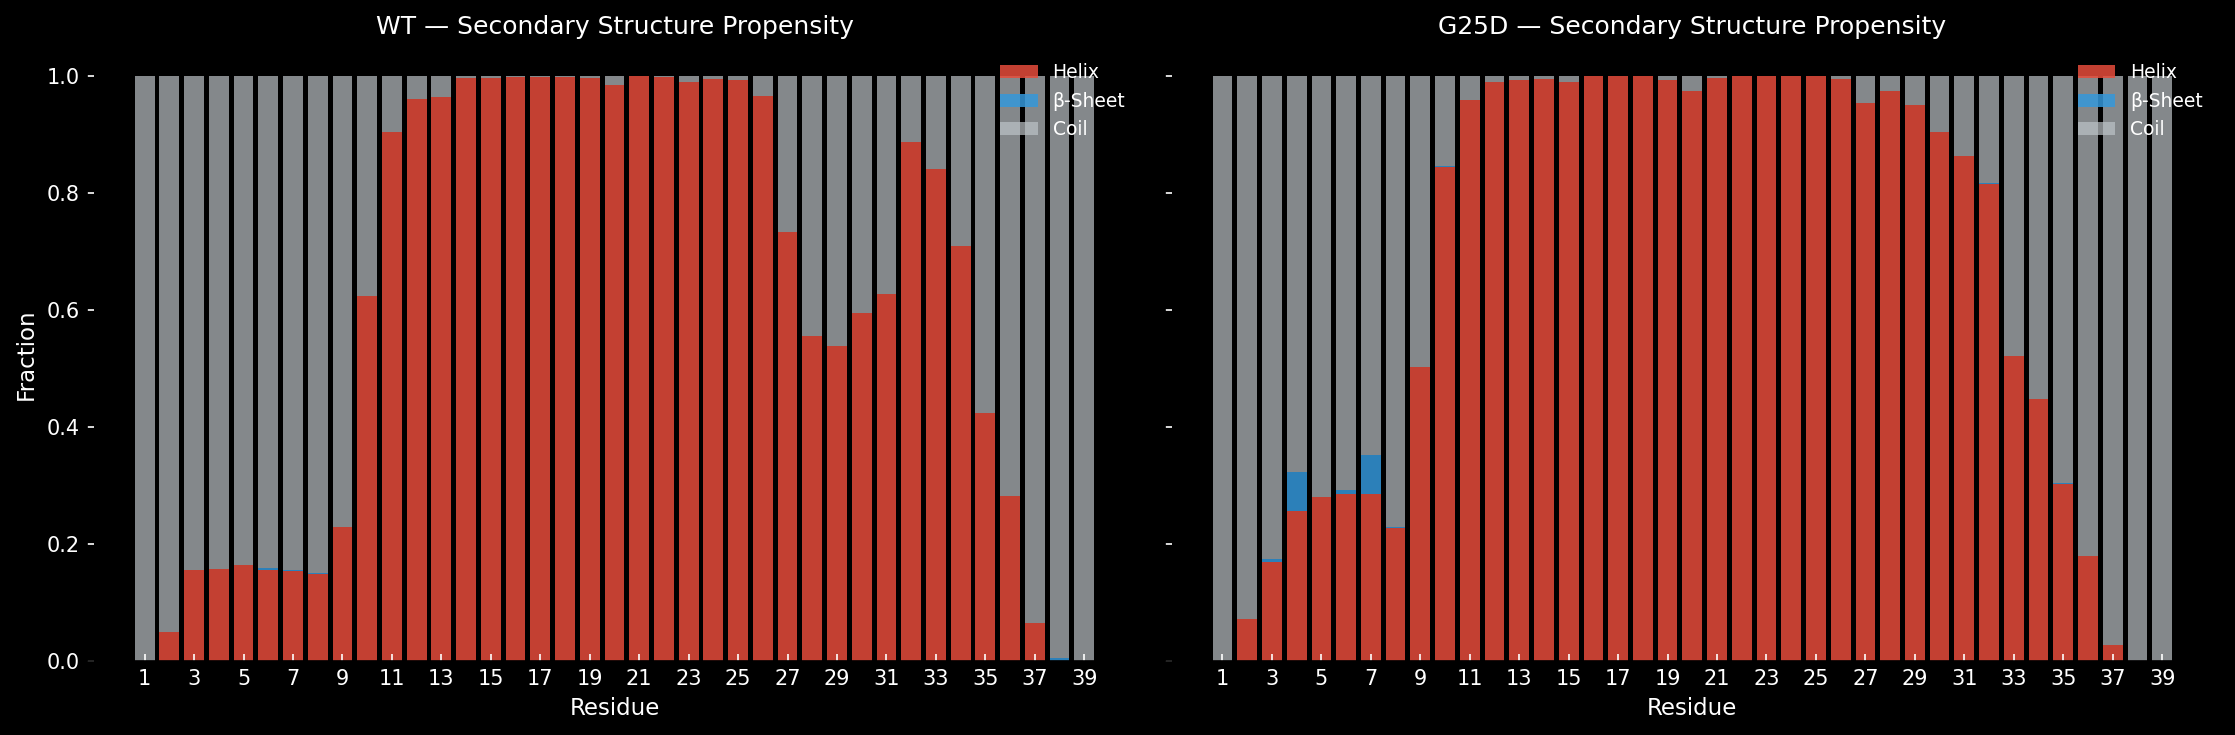

WT   → Helix: 61.1% | Sheet: 0.0% | Coil: 38.8%
G25D → Helix: 66.0% | Sheet: 0.4% | Coil: 33.6%


In [11]:
if dssp_available:
    n_res_dssp = S_oh_WT.shape[1]
    resids_dssp = resids[:n_res_dssp]

    # Compute fractions
    helix_WT   = S_oh_WT[:, :, 1].mean(axis=0)
    sheet_WT   = S_oh_WT[:, :, 2].mean(axis=0)
    coil_WT    = S_oh_WT[:, :, 0].mean(axis=0)

    helix_G25D = S_oh_G25D[:, :, 1].mean(axis=0)
    sheet_G25D = S_oh_G25D[:, :, 2].mean(axis=0)
    coil_G25D  = S_oh_G25D[:, :, 0].mean(axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

    # WT
    axes[0].bar(resids_dssp, helix_WT, label="Helix", color="#E74C3C", alpha=0.85)
    axes[0].bar(resids_dssp, sheet_WT, bottom=helix_WT, label="β-Sheet", color="#3498DB", alpha=0.85)
    axes[0].bar(resids_dssp, coil_WT, bottom=helix_WT+sheet_WT, label="Coil", color="#BDC3C7", alpha=0.7)
    axes[0].set_title("WT — Secondary Structure Propensity")
    axes[0].set_xlabel("Residue")
    axes[0].set_ylabel("Fraction")
    axes[0].set_ylim(0, 1.05)
    axes[0].legend(fontsize=9)
    axes[0].set_xticks(resids_dssp[::2])

    # G25D
    axes[1].bar(resids_dssp, helix_G25D, label="Helix", color="#E74C3C", alpha=0.85)
    axes[1].bar(resids_dssp, sheet_G25D, bottom=helix_G25D, label="β-Sheet", color="#3498DB", alpha=0.85)
    axes[1].bar(resids_dssp, coil_G25D, bottom=helix_G25D+sheet_G25D, label="Coil", color="#BDC3C7", alpha=0.7)
    axes[1].set_title("G25D — Secondary Structure Propensity")
    axes[1].set_xlabel("Residue")
    axes[1].set_ylim(0, 1.05)
    axes[1].legend(fontsize=9)
    axes[1].set_xticks(resids_dssp[::2])

    plt.tight_layout()
    plt.savefig("../../images/05a_dssp_propensity_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()

    print(f"WT   → Helix: {helix_WT.mean()*100:.1f}% | Sheet: {sheet_WT.mean()*100:.1f}% | Coil: {coil_WT.mean()*100:.1f}%")
    print(f"G25D → Helix: {helix_G25D.mean()*100:.1f}% | Sheet: {sheet_G25D.mean()*100:.1f}% | Coil: {coil_G25D.mean()*100:.1f}%")

## 6b. DSSP time-residue heatmap


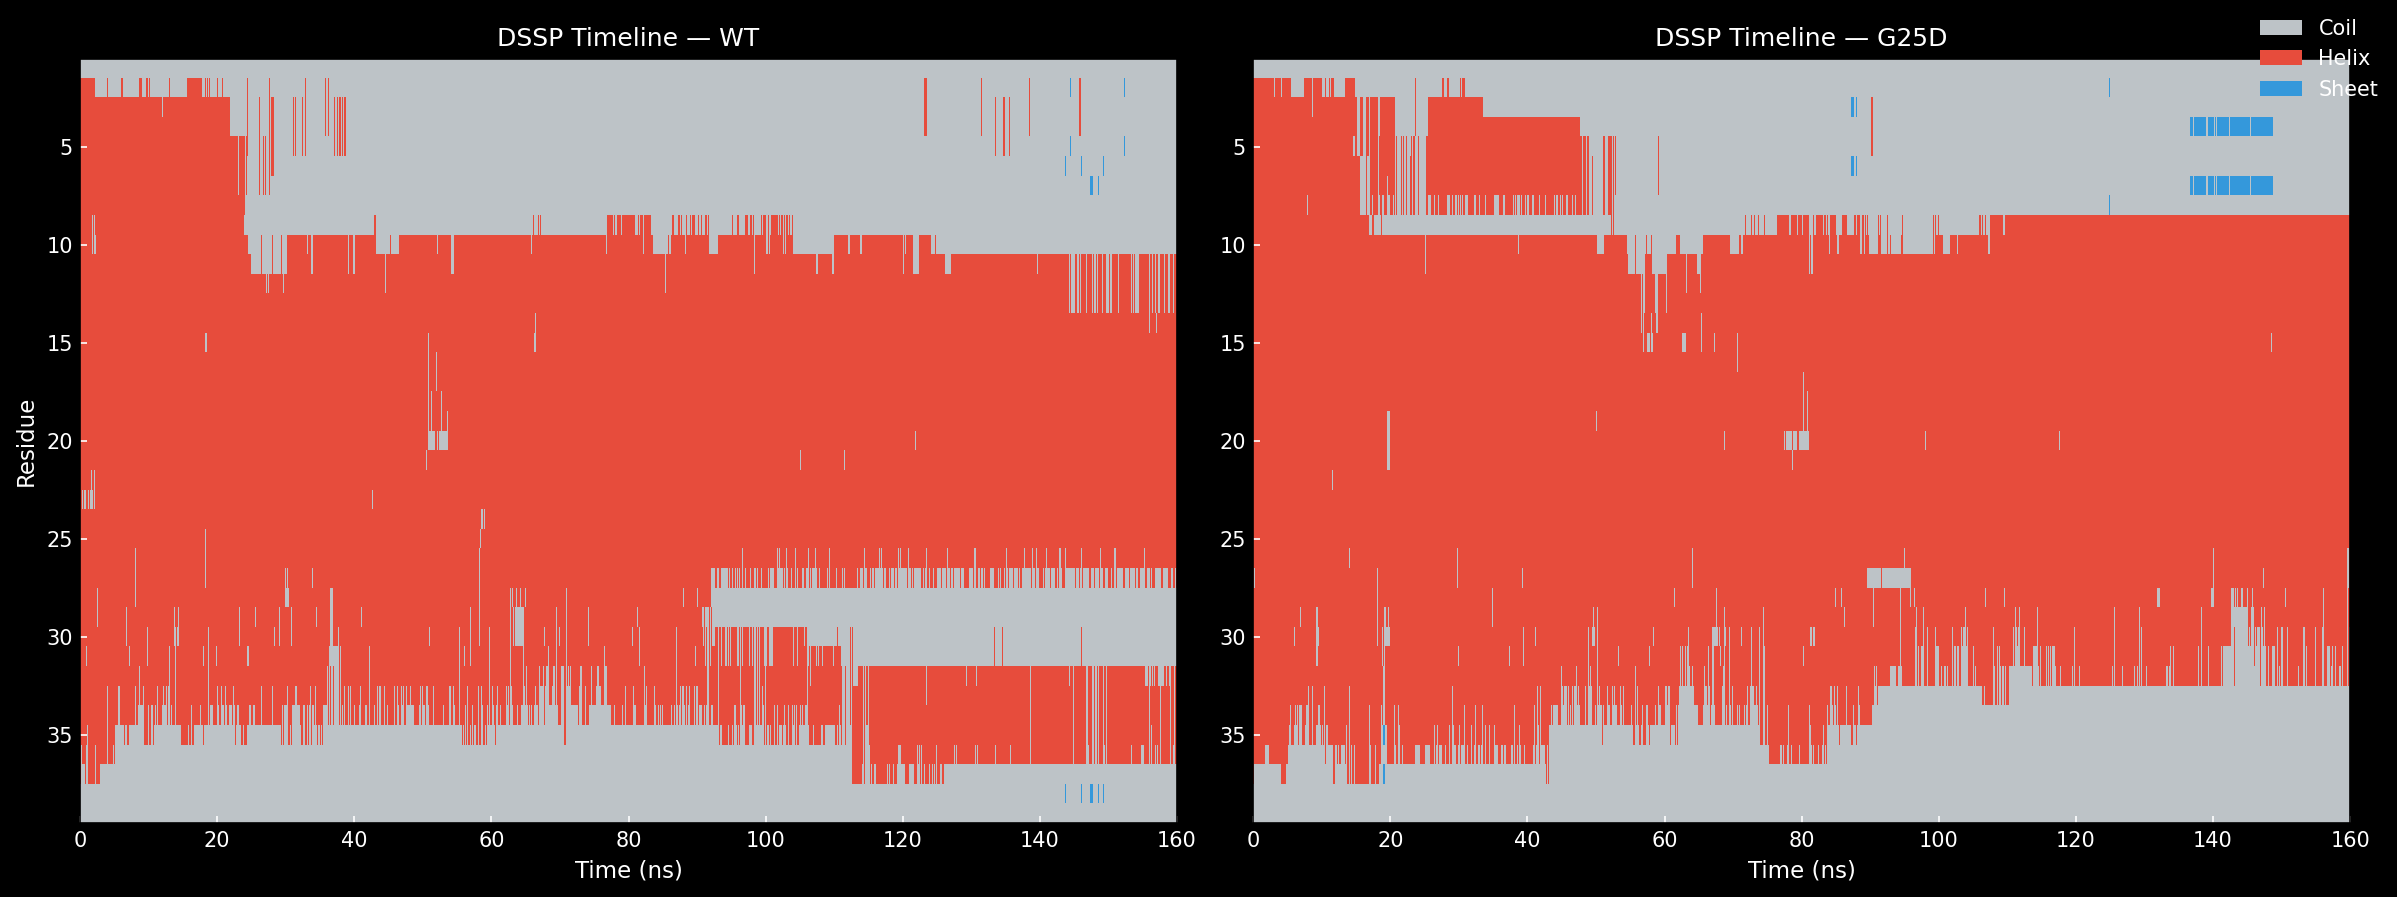

In [12]:
if dssp_available:
    from matplotlib.colors import ListedColormap
    from matplotlib.patches import Patch

    code_map_WT   = np.argmax(S_oh_WT, axis=-1).T
    code_map_G25D = np.argmax(S_oh_G25D, axis=-1).T

    cmap = ListedColormap(["#BDC3C7", "#E74C3C", "#3498DB"])

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # WT
    im0 = axes[0].imshow(code_map_WT, aspect="auto", interpolation="nearest", cmap=cmap,
                         extent=[0, total_ns, resids_dssp[-1]+0.5, resids_dssp[0]-0.5])
    axes[0].set_title("DSSP Timeline — WT")
    axes[0].set_xlabel("Time (ns)")
    axes[0].set_ylabel("Residue")

    # G25D
    im1 = axes[1].imshow(code_map_G25D, aspect="auto", interpolation="nearest", cmap=cmap,
                         extent=[0, total_ns, resids_dssp[-1]+0.5, resids_dssp[0]-0.5])
    axes[1].set_title("DSSP Timeline — G25D")
    axes[1].set_xlabel("Time (ns)")

    # Legend
    legend_elems = [
        Patch(facecolor="#BDC3C7", label="Coil"),
        Patch(facecolor="#E74C3C", label="Helix"),
        Patch(facecolor="#3498DB", label="Sheet")
    ]
    fig.legend(handles=legend_elems, loc="upper right", fontsize=10)

    plt.tight_layout()
    plt.savefig("../../images/05b_dssp_heatmap_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()

## 6c. β-sheet content over time


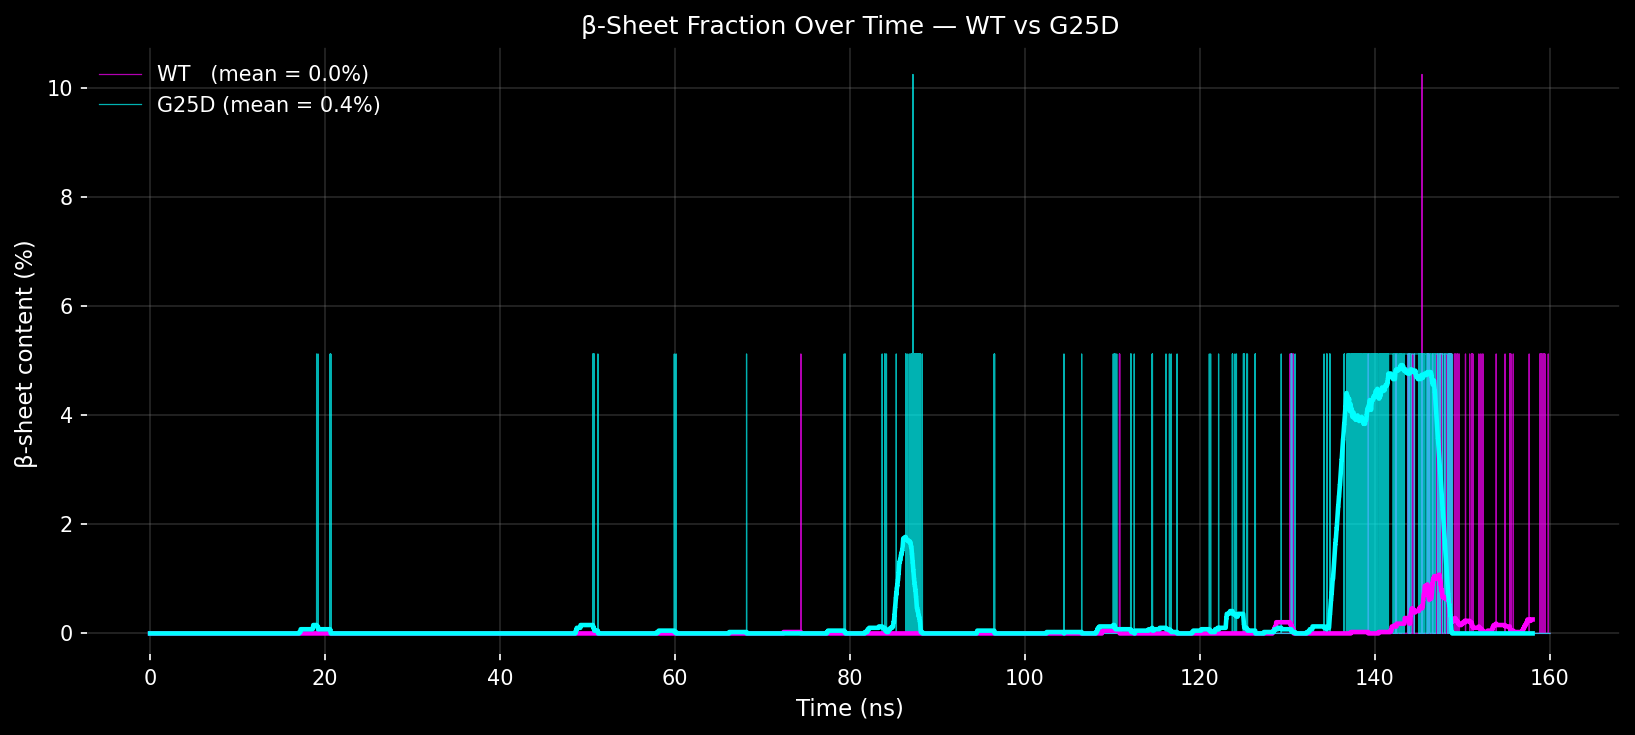

In [13]:
if dssp_available:
    sheet_WT   = S_oh_WT[:, :, 2].mean(axis=1) * 100
    sheet_G25D = S_oh_G25D[:, :, 2].mean(axis=1) * 100

    fig, ax = plt.subplots(figsize=(11, 5))

    ax.plot(time_ns, sheet_WT,   lw=0.6, alpha=0.7, color="magenta",
            label=f"WT   (mean = {sheet_WT.mean():.1f}%)")
    ax.plot(time_ns, sheet_G25D, lw=0.6, alpha=0.7, color="cyan",
            label=f"G25D (mean = {sheet_G25D.mean():.1f}%)")

    w = min(200, len(sheet_WT)//5)
    if w > 1:
        avg_WT   = np.convolve(sheet_WT,   np.ones(w)/w, mode='valid')
        avg_G25D = np.convolve(sheet_G25D, np.ones(w)/w, mode='valid')
        ax.plot(time_ns[:len(avg_WT)],   avg_WT,   lw=2.2, color="magenta")
        ax.plot(time_ns[:len(avg_G25D)], avg_G25D, lw=2.2, color="cyan")

    ax.set_xlabel("Time (ns)")
    ax.set_ylabel("β-sheet content (%)")
    ax.set_title("β-Sheet Fraction Over Time — WT vs G25D")
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("../../images/05c_beta_timeseries_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()

## 7. INTRAMOLECULAR HYDROGEN BONDS

In [14]:
def compute_hbonds(u, label):
    hba = HBA(universe=u,
              between=["protein", "protein"],
              d_a_cutoff=3.5,
              d_h_a_angle_cutoff=150,
              update_selections=False)
    hba.run()
    n_hb = hba.count_by_time()
    print(f"⟨H-bonds⟩ {label} = {n_hb.mean():.2f} ± {n_hb.std():.2f}")
    return n_hb


print("Computing intramolecular hydrogen bonds...")

n_hb_WT   = compute_hbonds(u_WT,   "WT")
n_hb_G25D = compute_hbonds(u_G25D, "G25D")

Computing intramolecular hydrogen bonds...
⟨H-bonds⟩ WT = 16.48 ± 3.72
⟨H-bonds⟩ G25D = 19.16 ± 3.58


## 7a. Hydrogen Bonds — Comparison Plot

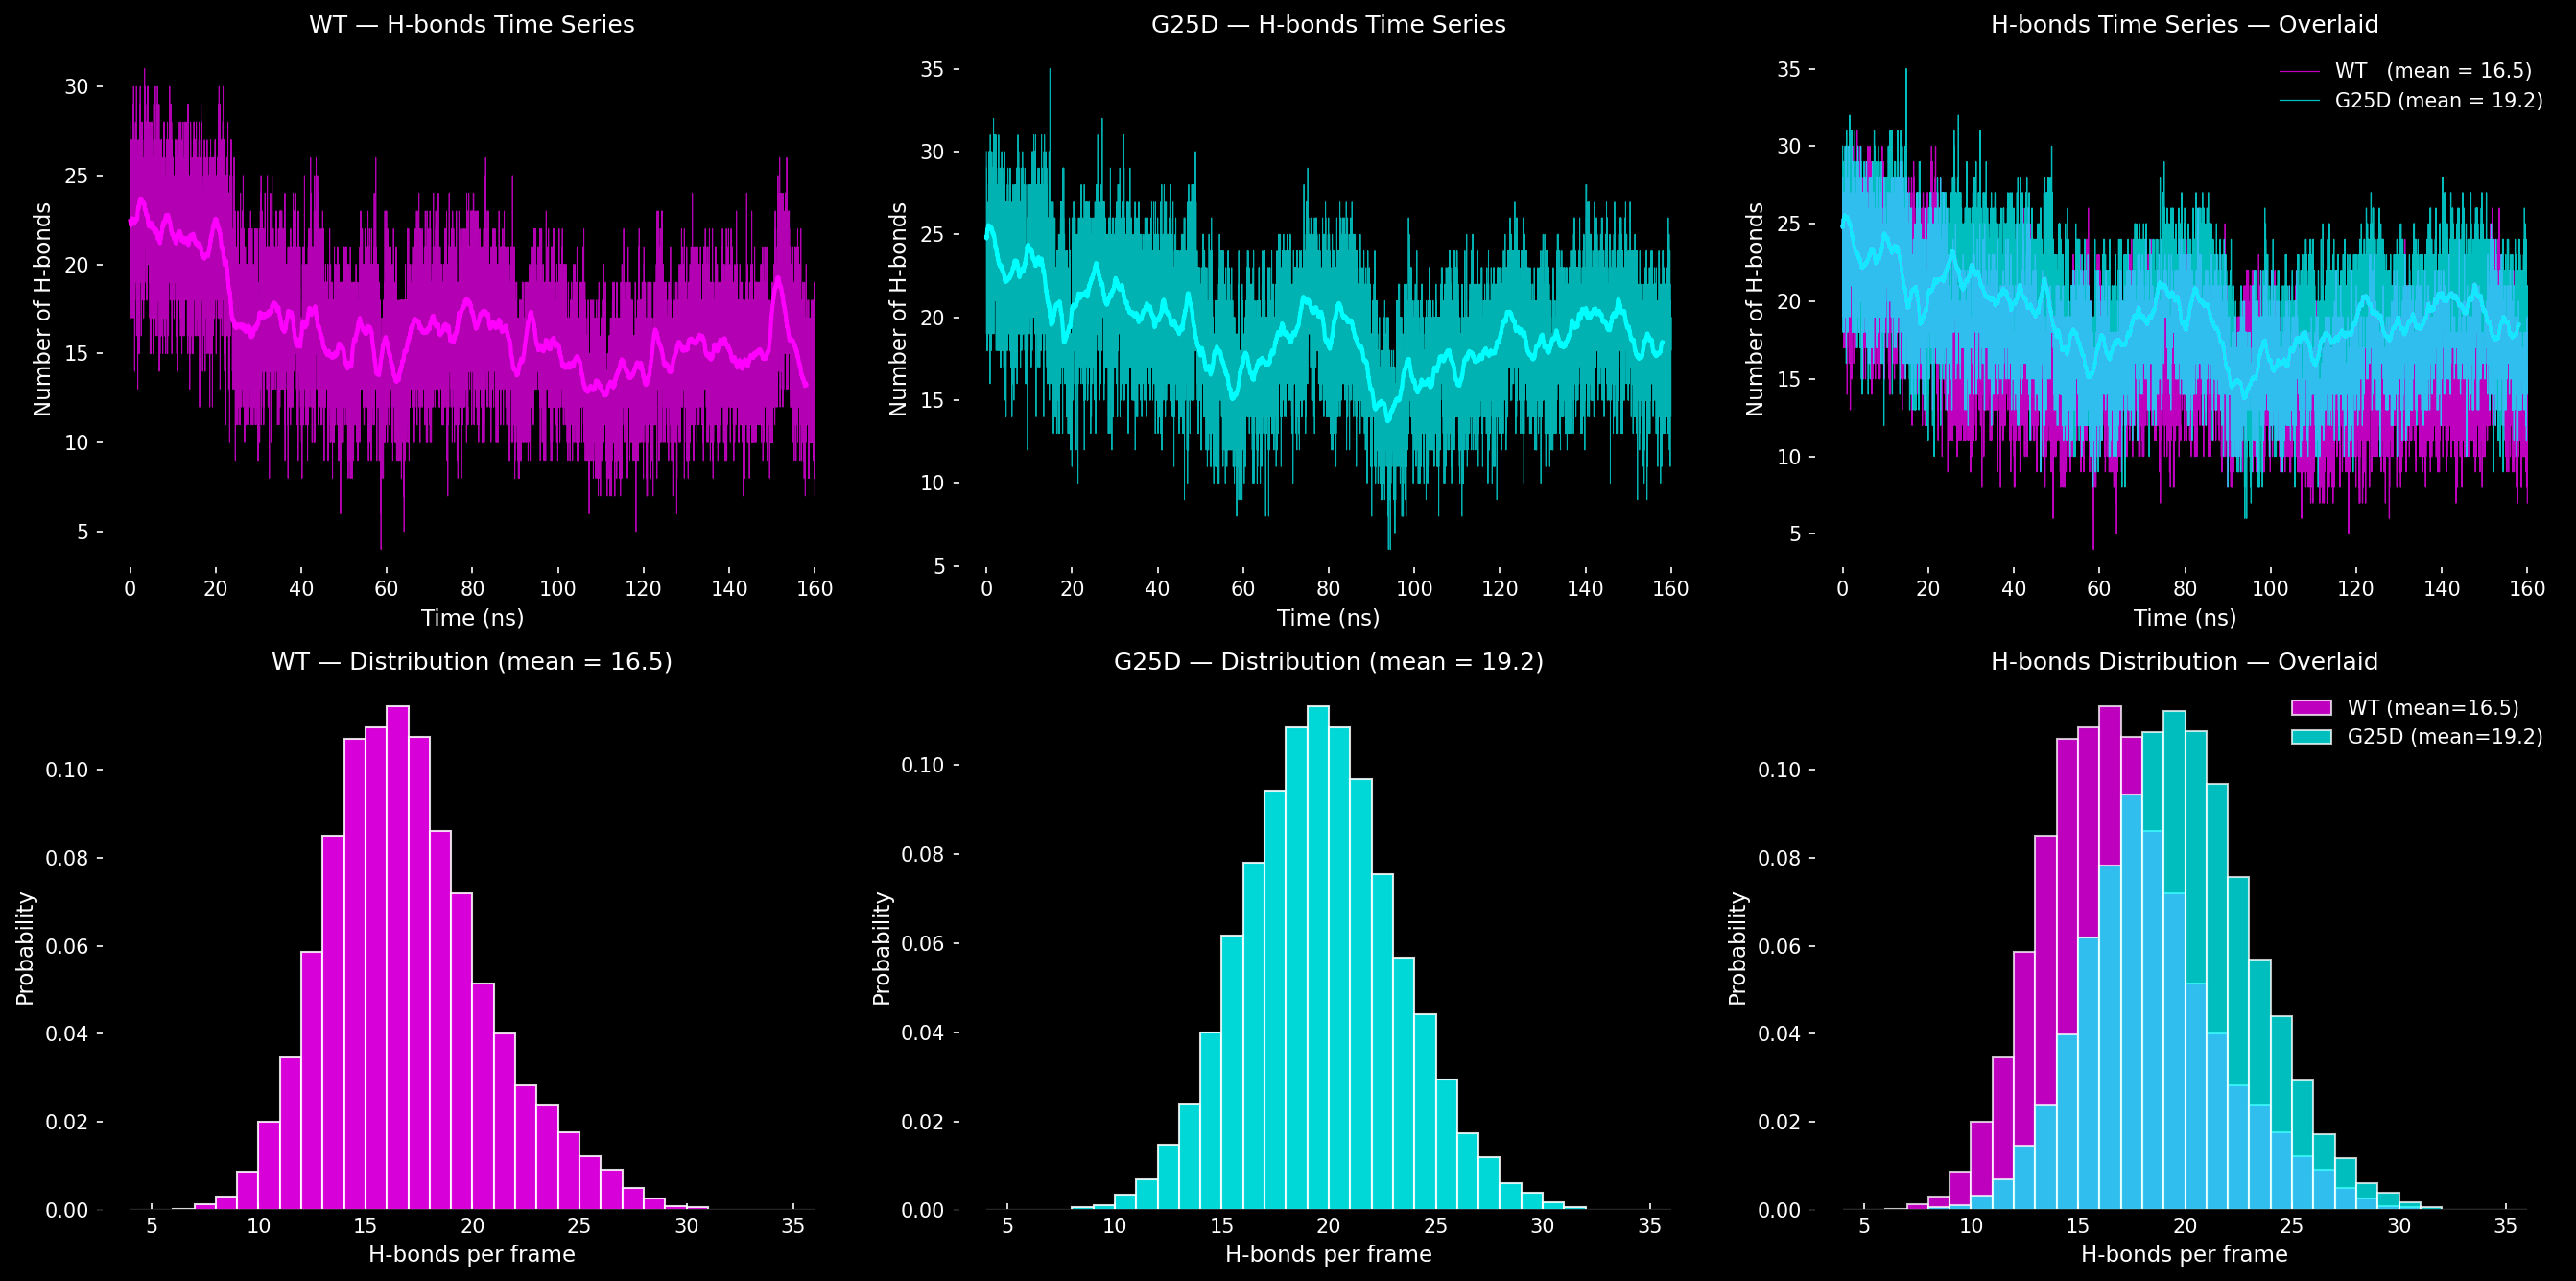

In [15]:
# Common bin range
hb_min = min(n_hb_WT.min(), n_hb_G25D.min())
hb_max = max(n_hb_WT.max(), n_hb_G25D.max())
bins = np.arange(hb_min, hb_max + 2)

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

# ==================== TIME SERIES ====================
# WT
axes[0, 0].plot(time_ns, n_hb_WT, lw=0.5, alpha=0.7, color=colors["WT"])
w = min(200, len(n_hb_WT)//5)
if w > 1:
    havg = np.convolve(n_hb_WT.astype(float), np.ones(w)/w, mode='valid')
    axes[0, 0].plot(time_ns[:len(havg)], havg, lw=2, color=colors["WT"])
axes[0, 0].set_title("WT — H-bonds Time Series")
axes[0, 0].set_xlabel("Time (ns)")
axes[0, 0].set_ylabel("Number of H-bonds")

# G25D
axes[0, 1].plot(time_ns, n_hb_G25D, lw=0.5, alpha=0.7, color=colors["G25D"])
if w > 1:
    havg = np.convolve(n_hb_G25D.astype(float), np.ones(w)/w, mode='valid')
    axes[0, 1].plot(time_ns[:len(havg)], havg, lw=2, color=colors["G25D"])
axes[0, 1].set_title("G25D — H-bonds Time Series")
axes[0, 1].set_xlabel("Time (ns)")
axes[0, 1].set_ylabel("Number of H-bonds")

# Overlaid
axes[0, 2].plot(time_ns, n_hb_WT,   lw=0.6, alpha=0.75, color=colors["WT"],
                label=f"WT   (mean = {n_hb_WT.mean():.1f})")
axes[0, 2].plot(time_ns, n_hb_G25D, lw=0.6, alpha=0.75, color=colors["G25D"],
                label=f"G25D (mean = {n_hb_G25D.mean():.1f})")
if w > 1:
    axes[0, 2].plot(time_ns[:len(havg)], havg, lw=2, color=colors["WT"], alpha=0.9)
    axes[0, 2].plot(time_ns[:len(havg)],
                    np.convolve(n_hb_G25D.astype(float), np.ones(w)/w, mode='valid'),
                    lw=2, color=colors["G25D"], alpha=0.9)
axes[0, 2].set_title("H-bonds Time Series — Overlaid")
axes[0, 2].set_xlabel("Time (ns)")
axes[0, 2].set_ylabel("Number of H-bonds")
axes[0, 2].legend(fontsize=10)

# ==================== DISTRIBUTIONS ====================
# WT histogram
axes[1, 0].hist(n_hb_WT, bins=bins, density=True, color=colors["WT"],
                edgecolor="white", alpha=0.85)
axes[1, 0].set_title(f"WT — Distribution (mean = {n_hb_WT.mean():.1f})")
axes[1, 0].set_xlabel("H-bonds per frame")
axes[1, 0].set_ylabel("Probability")

# G25D histogram
axes[1, 1].hist(n_hb_G25D, bins=bins, density=True, color=colors["G25D"],
                edgecolor="white", alpha=0.85)
axes[1, 1].set_title(f"G25D — Distribution (mean = {n_hb_G25D.mean():.1f})")
axes[1, 1].set_xlabel("H-bonds per frame")
axes[1, 1].set_ylabel("Probability")

# Overlaid distributions
axes[1, 2].hist(n_hb_WT,   bins=bins, density=True, alpha=0.75,
                color=colors["WT"], label=f"WT (mean={n_hb_WT.mean():.1f})", edgecolor="white")
axes[1, 2].hist(n_hb_G25D, bins=bins, density=True, alpha=0.75,
                color=colors["G25D"], label=f"G25D (mean={n_hb_G25D.mean():.1f})", edgecolor="white")
axes[1, 2].set_title("H-bonds Distribution — Overlaid")
axes[1, 2].set_xlabel("H-bonds per frame")
axes[1, 2].set_ylabel("Probability")
axes[1, 2].legend(fontsize=10)

plt.tight_layout()
plt.savefig("../../images/06_hbonds_comparison_2x3.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Salt bridges (D23–K28 and E22–K28)

Computing salt bridges...
WT:   D23–K28 = 0.0% | E22–K28 = 0.0%
G25D: D23–K28 = 0.0% | E22–K28 = 0.0%


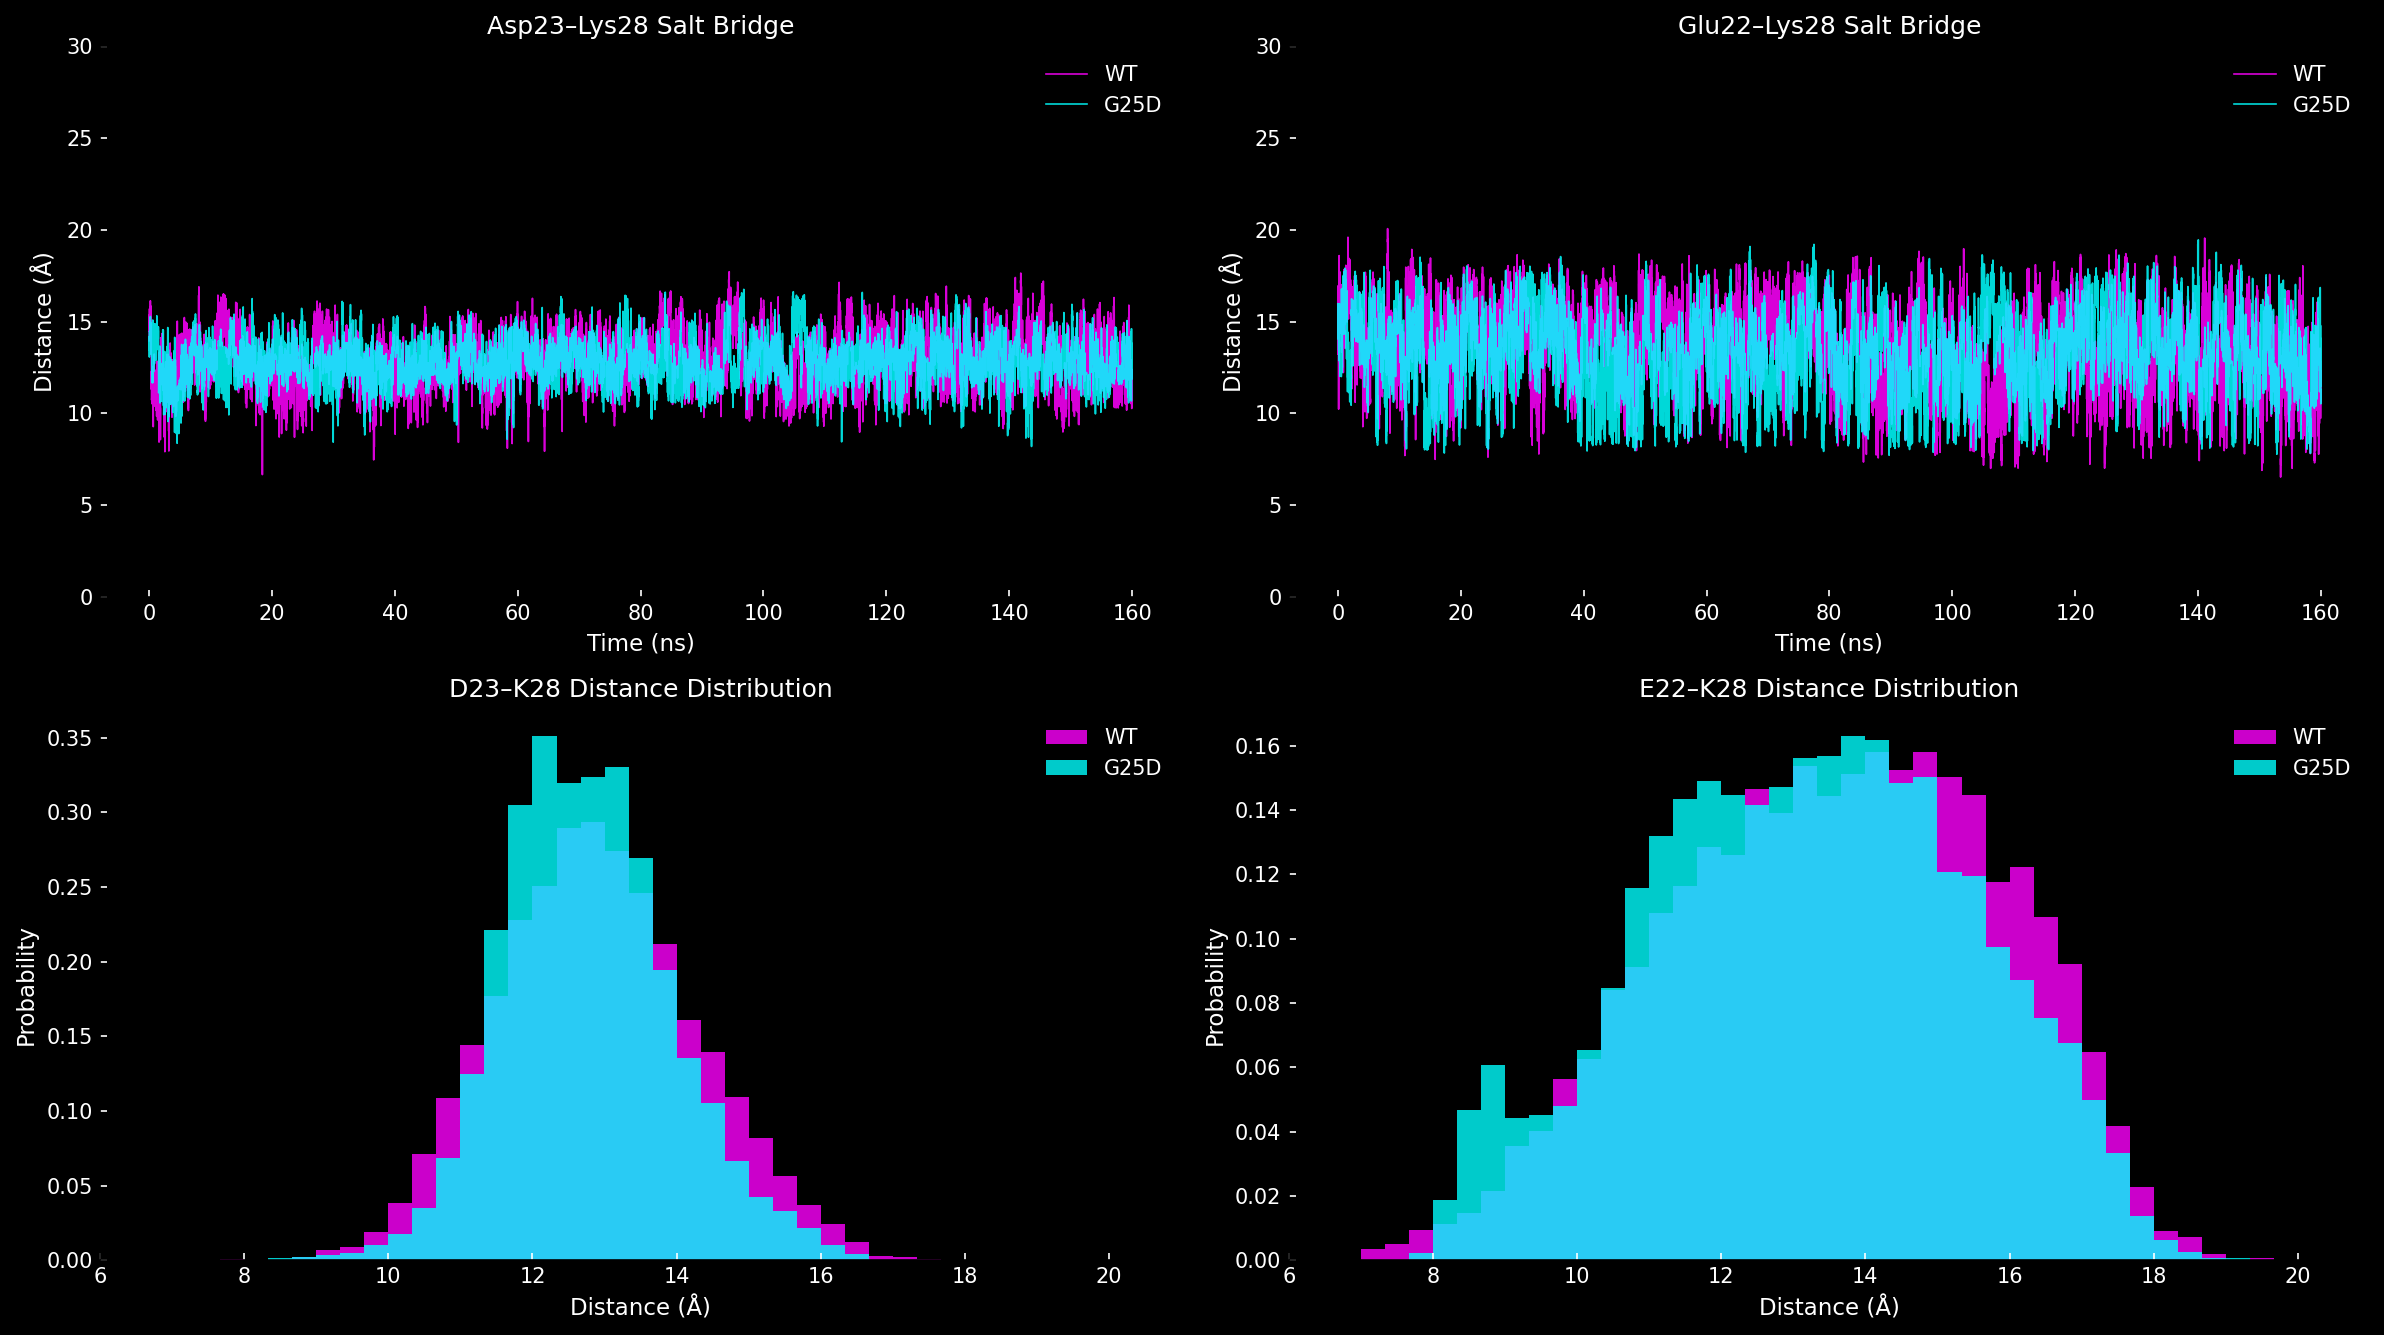

In [16]:
def compute_salt_bridges(u):
    asp23_O = u.select_atoms("resid 23 and name OD1 OD2")
    glu22_O = u.select_atoms("resid 22 and name OE1 OE2")
    lys28_N = u.select_atoms("resid 28 and name NZ")
  
    d_d23k28 = np.empty(u.trajectory.n_frames)
    d_e22k28 = np.empty(u.trajectory.n_frames)
  
    for i, ts in enumerate(u.trajectory):
        d_d23k28[i] = distances.distance_array(asp23_O.positions, lys28_N.positions,
                                               box=ts.dimensions).min()
        d_e22k28[i] = distances.distance_array(glu22_O.positions, lys28_N.positions,
                                               box=ts.dimensions).min()
  
    return d_d23k28, d_e22k28


print("Computing salt bridges...")

d_d23k28_WT, d_e22k28_WT = compute_salt_bridges(u_WT)
d_d23k28_G25D, d_e22k28_G25D = compute_salt_bridges(u_G25D)

sb_cutoff = 4.0

occ_d23_WT   = (d_d23k28_WT   <= sb_cutoff).mean() * 100
occ_e22_WT   = (d_e22k28_WT   <= sb_cutoff).mean() * 100
occ_d23_G25D = (d_d23k28_G25D <= sb_cutoff).mean() * 100
occ_e22_G25D = (d_e22k28_G25D <= sb_cutoff).mean() * 100

print(f"WT:   D23–K28 = {occ_d23_WT:.1f}% | E22–K28 = {occ_e22_WT:.1f}%")
print(f"G25D: D23–K28 = {occ_d23_G25D:.1f}% | E22–K28 = {occ_e22_G25D:.1f}%")


# ============================================================
# Visualization
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 9))

# D23–K28 Time Series
axes[0, 0].plot(time_ns, d_d23k28_WT,   lw=0.8, alpha=0.85, color=colors["WT"],   label="WT")
axes[0, 0].plot(time_ns, d_d23k28_G25D, lw=0.8, alpha=0.85, color=colors["G25D"], label="G25D")
axes[0, 0].axhline(sb_cutoff, ls="--", color="black", alpha=0.7, lw=1.2)
axes[0, 0].set_ylabel("Distance (Å)")
axes[0, 0].set_title("Asp23–Lys28 Salt Bridge")
axes[0, 0].set_ylim(0, 30)
axes[0, 0].legend(fontsize=10)
axes[0, 0].set_xlabel("Time (ns)")

# D23–K28 Distribution
axes[1, 0].hist(d_d23k28_WT,   bins=60, range=(0, 20), alpha=0.8, color=colors["WT"],   label="WT", density=True)
axes[1, 0].hist(d_d23k28_G25D, bins=60, range=(0, 20), alpha=0.8, color=colors["G25D"], label="G25D", density=True)
axes[1, 0].axvline(sb_cutoff, ls="--", color="black", alpha=0.8, lw=1.5)
axes[1, 0].set_xlim(6, 21)
axes[1, 0].set_xlabel("Distance (Å)")
axes[1, 0].set_ylabel("Probability")
axes[1, 0].set_title("D23–K28 Distance Distribution")
axes[1, 0].legend()

# E22–K28 Time Series
axes[0, 1].plot(time_ns, d_e22k28_WT,   lw=0.8, alpha=0.85, color=colors["WT"],   label="WT")
axes[0, 1].plot(time_ns, d_e22k28_G25D, lw=0.8, alpha=0.85, color=colors["G25D"], label="G25D")
axes[0, 1].axhline(sb_cutoff, ls="--", color="black", alpha=0.7, lw=1.2)
axes[0, 1].set_ylabel("Distance (Å)")
axes[0, 1].set_title("Glu22–Lys28 Salt Bridge")
axes[0, 1].set_ylim(0, 30)
axes[0, 1].legend(fontsize=10)
axes[0, 1].set_xlabel("Time (ns)")

# E22–K28 Distribution
axes[1, 1].hist(d_e22k28_WT,   bins=60, range=(0, 20), alpha=0.8, color=colors["WT"],   label="WT", density=True)
axes[1, 1].hist(d_e22k28_G25D, bins=60, range=(0, 20), alpha=0.8, color=colors["G25D"], label="G25D", density=True)
axes[1, 1].axvline(sb_cutoff, ls="--", color="black", alpha=0.8, lw=1.5)
axes[1, 1].set_xlim(6, 21)
axes[1, 1].set_xlabel("Distance (Å)")
axes[1, 1].set_ylabel("Probability")
axes[1, 1].set_title("E22–K28 Distance Distribution")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig("../../images/07_salt_bridges_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Contact map

In [17]:
CONTACT_CUTOFF = 10.0

def compute_contact_map(ca_atoms, u):
    n_res = ca_atoms.n_residues
    sum_contact = np.zeros((n_res, n_res))
    
    for ts in u.trajectory:
        d = distances.distance_array(ca_atoms.positions, ca_atoms.positions, box=ts.dimensions)
        sum_contact += (d < CONTACT_CUTOFF).astype(float)
    
    contact_freq = sum_contact / u.trajectory.n_frames
    return contact_freq


print("Computing contact maps...")

contact_WT   = compute_contact_map(ca_WT,   u_WT)
contact_G25D = compute_contact_map(ca_G25D, u_G25D)

n_res = ca_WT.n_residues
seq_mask = np.abs(np.subtract.outer(np.arange(n_res), np.arange(n_res))) < 4

Computing contact maps...


## 9a. Contact Maps — Side-by-side + Difference

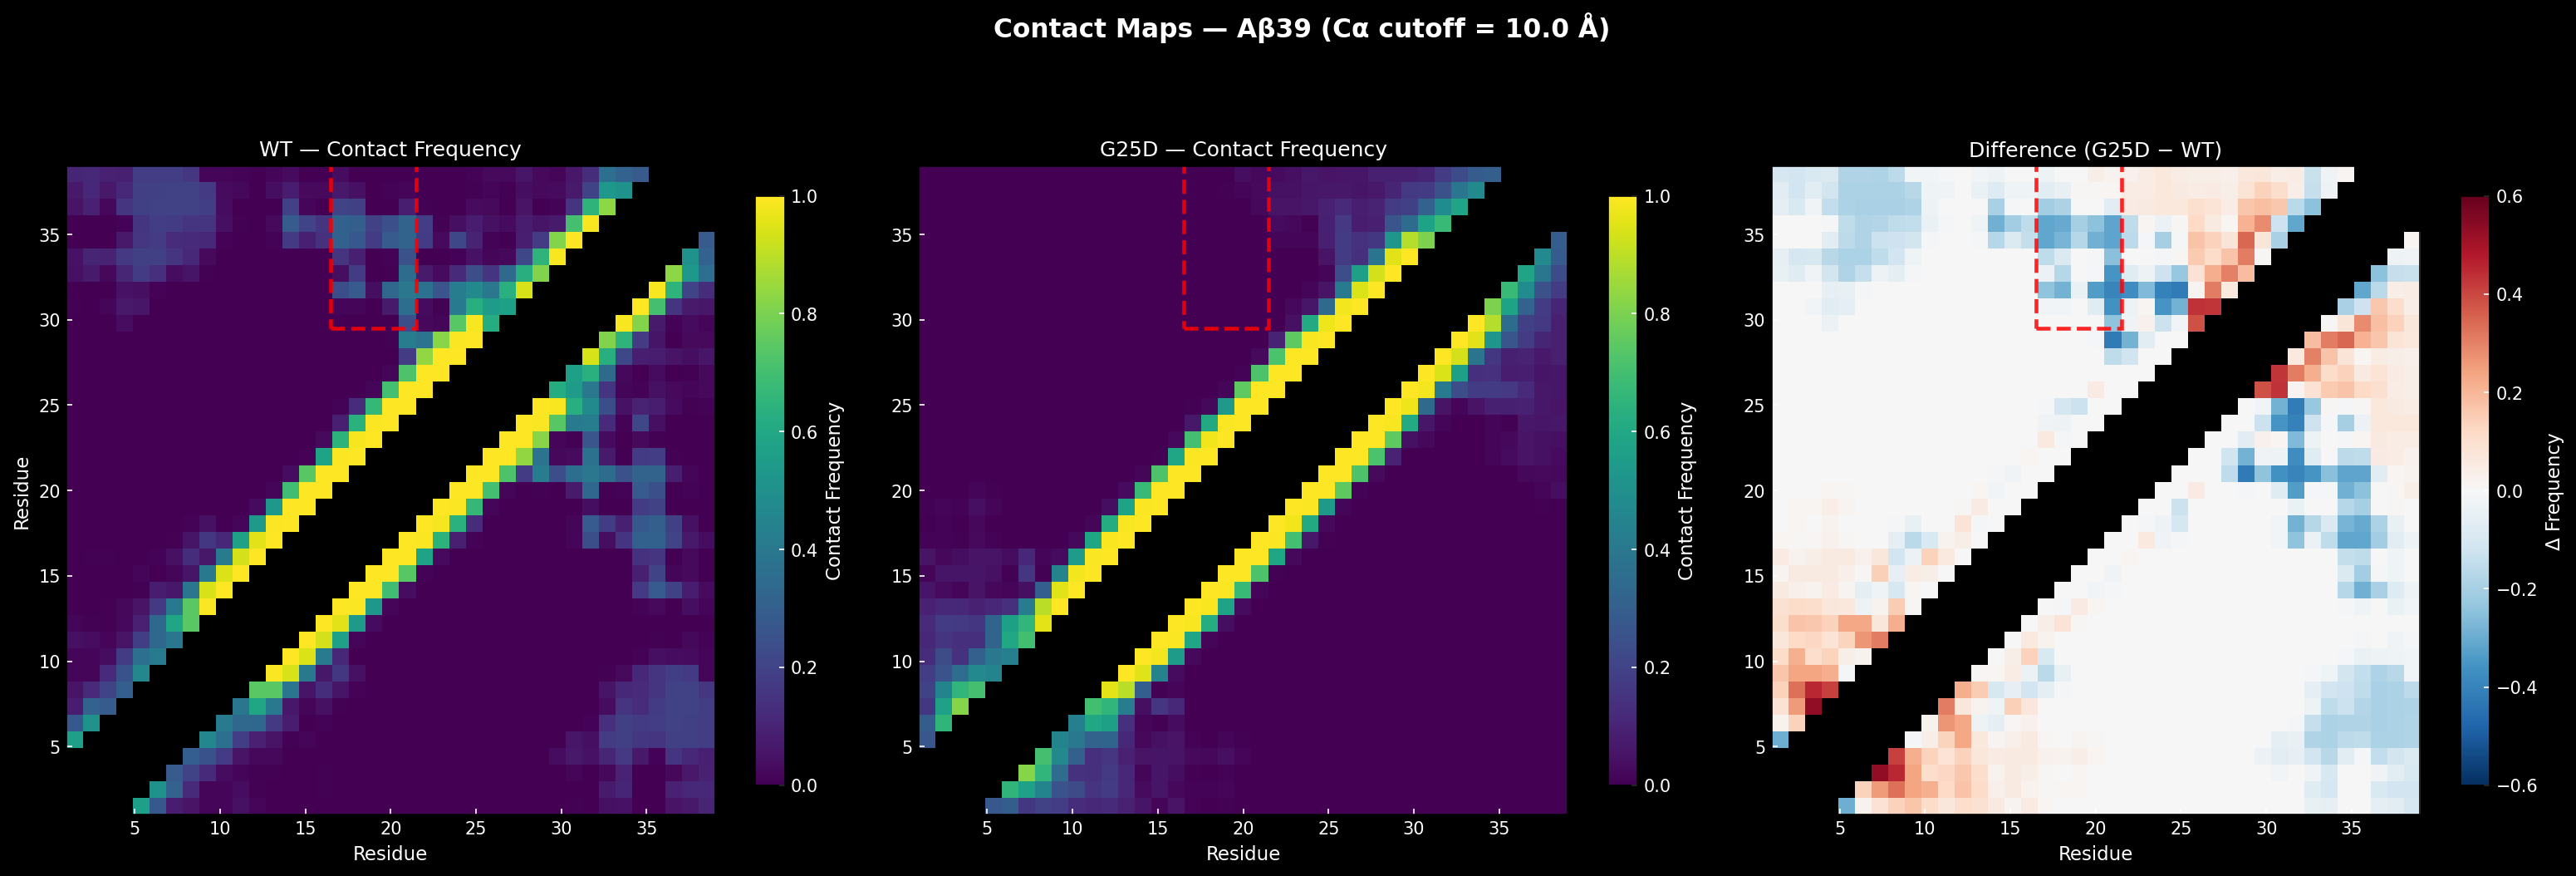

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

# WT
cf_WT = contact_WT.copy()
cf_WT[seq_mask] = np.nan
im1 = axes[0].imshow(cf_WT, cmap="viridis", origin="lower",
                     extent=[resids[0], resids[-1], resids[0], resids[-1]], 
                     vmin=0, vmax=1.0)
axes[0].set_title("WT — Contact Frequency")
axes[0].set_xlabel("Residue")
axes[0].set_ylabel("Residue")
plt.colorbar(im1, ax=axes[0], label="Contact Frequency", shrink=0.75)

# G25D
cf_G25D = contact_G25D.copy()
cf_G25D[seq_mask] = np.nan
im2 = axes[1].imshow(cf_G25D, cmap="viridis", origin="lower",
                     extent=[resids[0], resids[-1], resids[0], resids[-1]], 
                     vmin=0, vmax=1.0)
axes[1].set_title("G25D — Contact Frequency")
axes[1].set_xlabel("Residue")
plt.colorbar(im2, ax=axes[1], label="Contact Frequency", shrink=0.75)

# Difference
diff_map = contact_G25D - contact_WT
diff_map[seq_mask] = np.nan
im3 = axes[2].imshow(diff_map, cmap="RdBu_r", origin="lower",
                     extent=[resids[0], resids[-1], resids[0], resids[-1]], 
                     vmin=-0.6, vmax=0.6)
axes[2].set_title("Difference (G25D − WT)")
axes[2].set_xlabel("Residue")
plt.colorbar(im3, ax=axes[2], label="Δ Frequency", shrink=0.75)

# Highlight CHC–C-term region
from matplotlib.patches import Rectangle
for ax in axes:
    rect = Rectangle((16.5, 29.5), 5, 13, lw=2.2, edgecolor="red", 
                     facecolor="none", ls="--", alpha=0.85)
    ax.add_patch(rect)

plt.suptitle(f"Contact Maps — Aβ39 (Cα cutoff = {CONTACT_CUTOFF} Å)", 
             fontsize=15, fontweight="bold", y=1.02)

plt.tight_layout()
plt.savefig("../../images/08_contact_maps_comparison.png", dpi=400, bbox_inches="tight")
plt.savefig("../../images/08_contact_maps_comparison.pdf", bbox_inches="tight")
plt.show()

## 10. CHC Analysis — Central Hydrophobic Cluster

Computing CHC analysis...
WT: ⟨CHC Rg⟩ = 5.43 Å | ⟨CHC–Cterm min dist⟩ = 9.51 Å
WT: Collapsed fraction = 2.0%
G25D: ⟨CHC Rg⟩ = 5.48 Å | ⟨CHC–Cterm min dist⟩ = 12.77 Å
G25D: Collapsed fraction = 0.0%


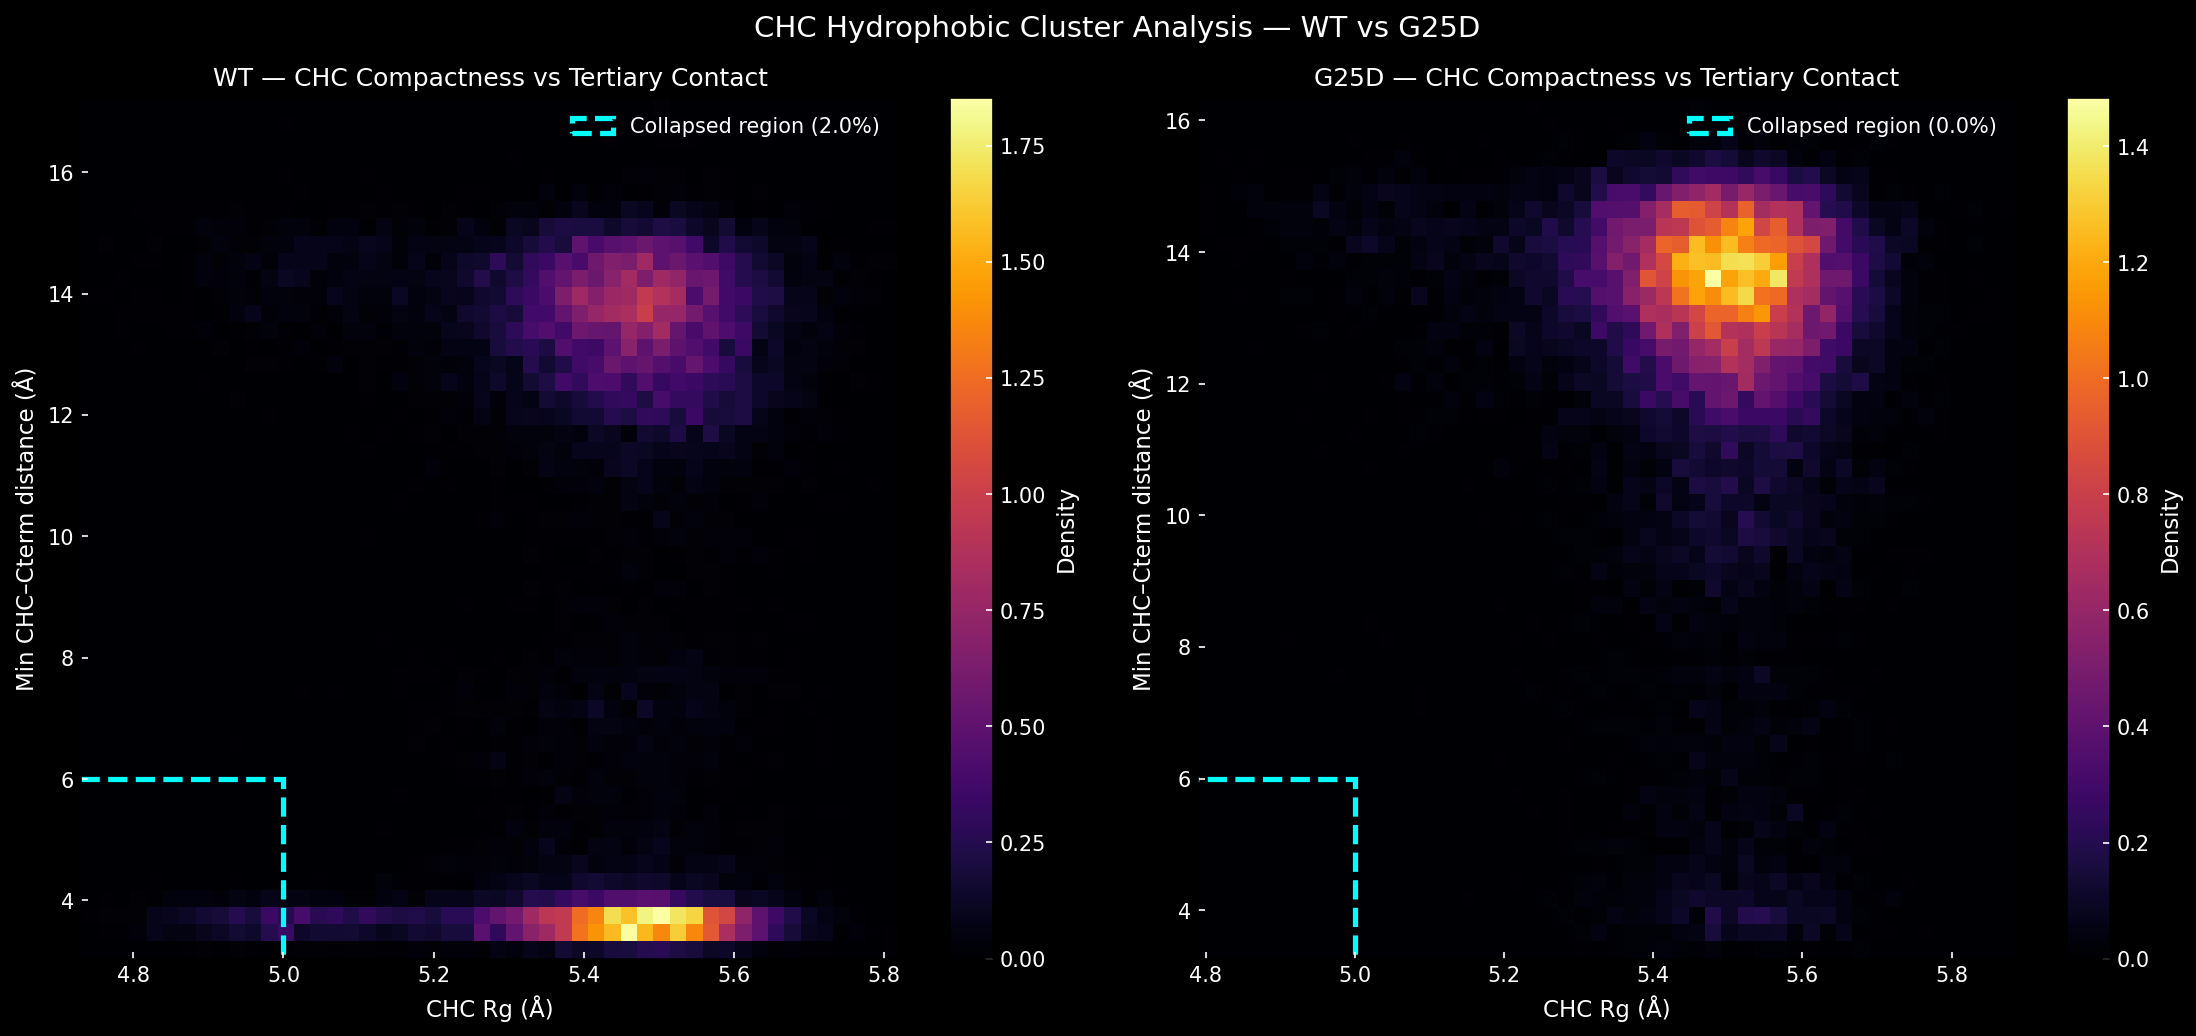

In [19]:
def compute_chc_analysis(u, ca_atoms, label):
    chc_sc = u.select_atoms("resid 17:21 and not name N CA C O H* HN HA")
    cterm_sc = u.select_atoms(f"resid 30:{ca_atoms.n_residues} and not name N CA C O H* HN HA")
    
    chc_rg = np.empty(u.trajectory.n_frames)
    chc_cterm_d = np.empty(u.trajectory.n_frames)
    
    for i, ts in enumerate(u.trajectory):
        chc_rg[i] = chc_sc.radius_of_gyration()
        d = distances.distance_array(chc_sc.positions, cterm_sc.positions, box=ts.dimensions)
        chc_cterm_d[i] = d.min()
    
    collapsed = (chc_rg < 5.0) & (chc_cterm_d < 6.0)
    frac = collapsed.mean() * 100
    
    print(f"{label}: ⟨CHC Rg⟩ = {chc_rg.mean():.2f} Å | ⟨CHC–Cterm min dist⟩ = {chc_cterm_d.mean():.2f} Å")
    print(f"{label}: Collapsed fraction = {frac:.1f}%")
    
    return chc_rg, chc_cterm_d, frac


print("Computing CHC analysis...")

chc_rg_WT, chc_cterm_d_WT, frac_WT = compute_chc_analysis(u_WT, ca_WT, "WT")
chc_rg_G25D, chc_cterm_d_G25D, frac_G25D = compute_chc_analysis(u_G25D, ca_G25D, "G25D")


# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# WT
h1 = axes[0].hist2d(chc_rg_WT, chc_cterm_d_WT, bins=50, cmap="inferno", density=True)
plt.colorbar(h1[3], ax=axes[0], label="Density")
r1 = Rectangle((0, 0), 5.0, 6.0, lw=2.5, edgecolor="cyan", facecolor="none", ls="--",
               label=f"Collapsed region ({frac_WT:.1f}%)")
axes[0].add_patch(r1)
axes[0].set_xlabel("CHC Rg (Å)")
axes[0].set_ylabel("Min CHC–Cterm distance (Å)")
axes[0].set_title("WT — CHC Compactness vs Tertiary Contact")
axes[0].legend()

# G25D
h2 = axes[1].hist2d(chc_rg_G25D, chc_cterm_d_G25D, bins=50, cmap="inferno", density=True)
plt.colorbar(h2[3], ax=axes[1], label="Density")
r2 = Rectangle((0, 0), 5.0, 6.0, lw=2.5, edgecolor="cyan", facecolor="none", ls="--",
               label=f"Collapsed region ({frac_G25D:.1f}%)")
axes[1].add_patch(r2)
axes[1].set_xlabel("CHC Rg (Å)")
axes[1].set_ylabel("Min CHC–Cterm distance (Å)")
axes[1].set_title("G25D — CHC Compactness vs Tertiary Contact")
axes[1].legend()

plt.suptitle("CHC Hydrophobic Cluster Analysis — WT vs G25D", fontsize=14)
plt.tight_layout()
plt.savefig("../../images/09_chc_analysis_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. PCA — Principal Component Analysis

In [20]:
def run_pca(u, label):
    print(f"Running PCA for {label}...")
    pc = pca.PCA(u, select="protein and name CA", 
                 align=True, mean=None).run()
    
    cum_var = pc.results.cumulated_variance
    proj = pc.transform(u.select_atoms("protein and name CA"), n_components=3)
    
    # Cosine content
    cc = [pca.cosine_content(proj, i) for i in range(3)]
    
    print(f"Cosine content {label}:")
    for i, c in enumerate(cc):
        tag = "✅" if c < 0.2 else ("⚠️" if c < 0.5 else "❌")
        print(f"   PC{i+1}: {c:.3f} {tag}")
    
    return pc, cum_var, proj, cc


# Run PCA
pc_WT,   cum_var_WT,   proj_WT,   cc_WT   = run_pca(u_WT,   "WT")
pc_G25D, cum_var_G25D, proj_G25D, cc_G25D = run_pca(u_G25D, "G25D")

Running PCA for WT...
Cosine content WT:
   PC1: 0.780 ❌
   PC2: 0.028 ✅
   PC3: 0.163 ✅
Running PCA for G25D...
Cosine content G25D:
   PC1: 0.330 ⚠️
   PC2: 0.000 ✅
   PC3: 0.039 ✅


## 11a. PCA Visualization

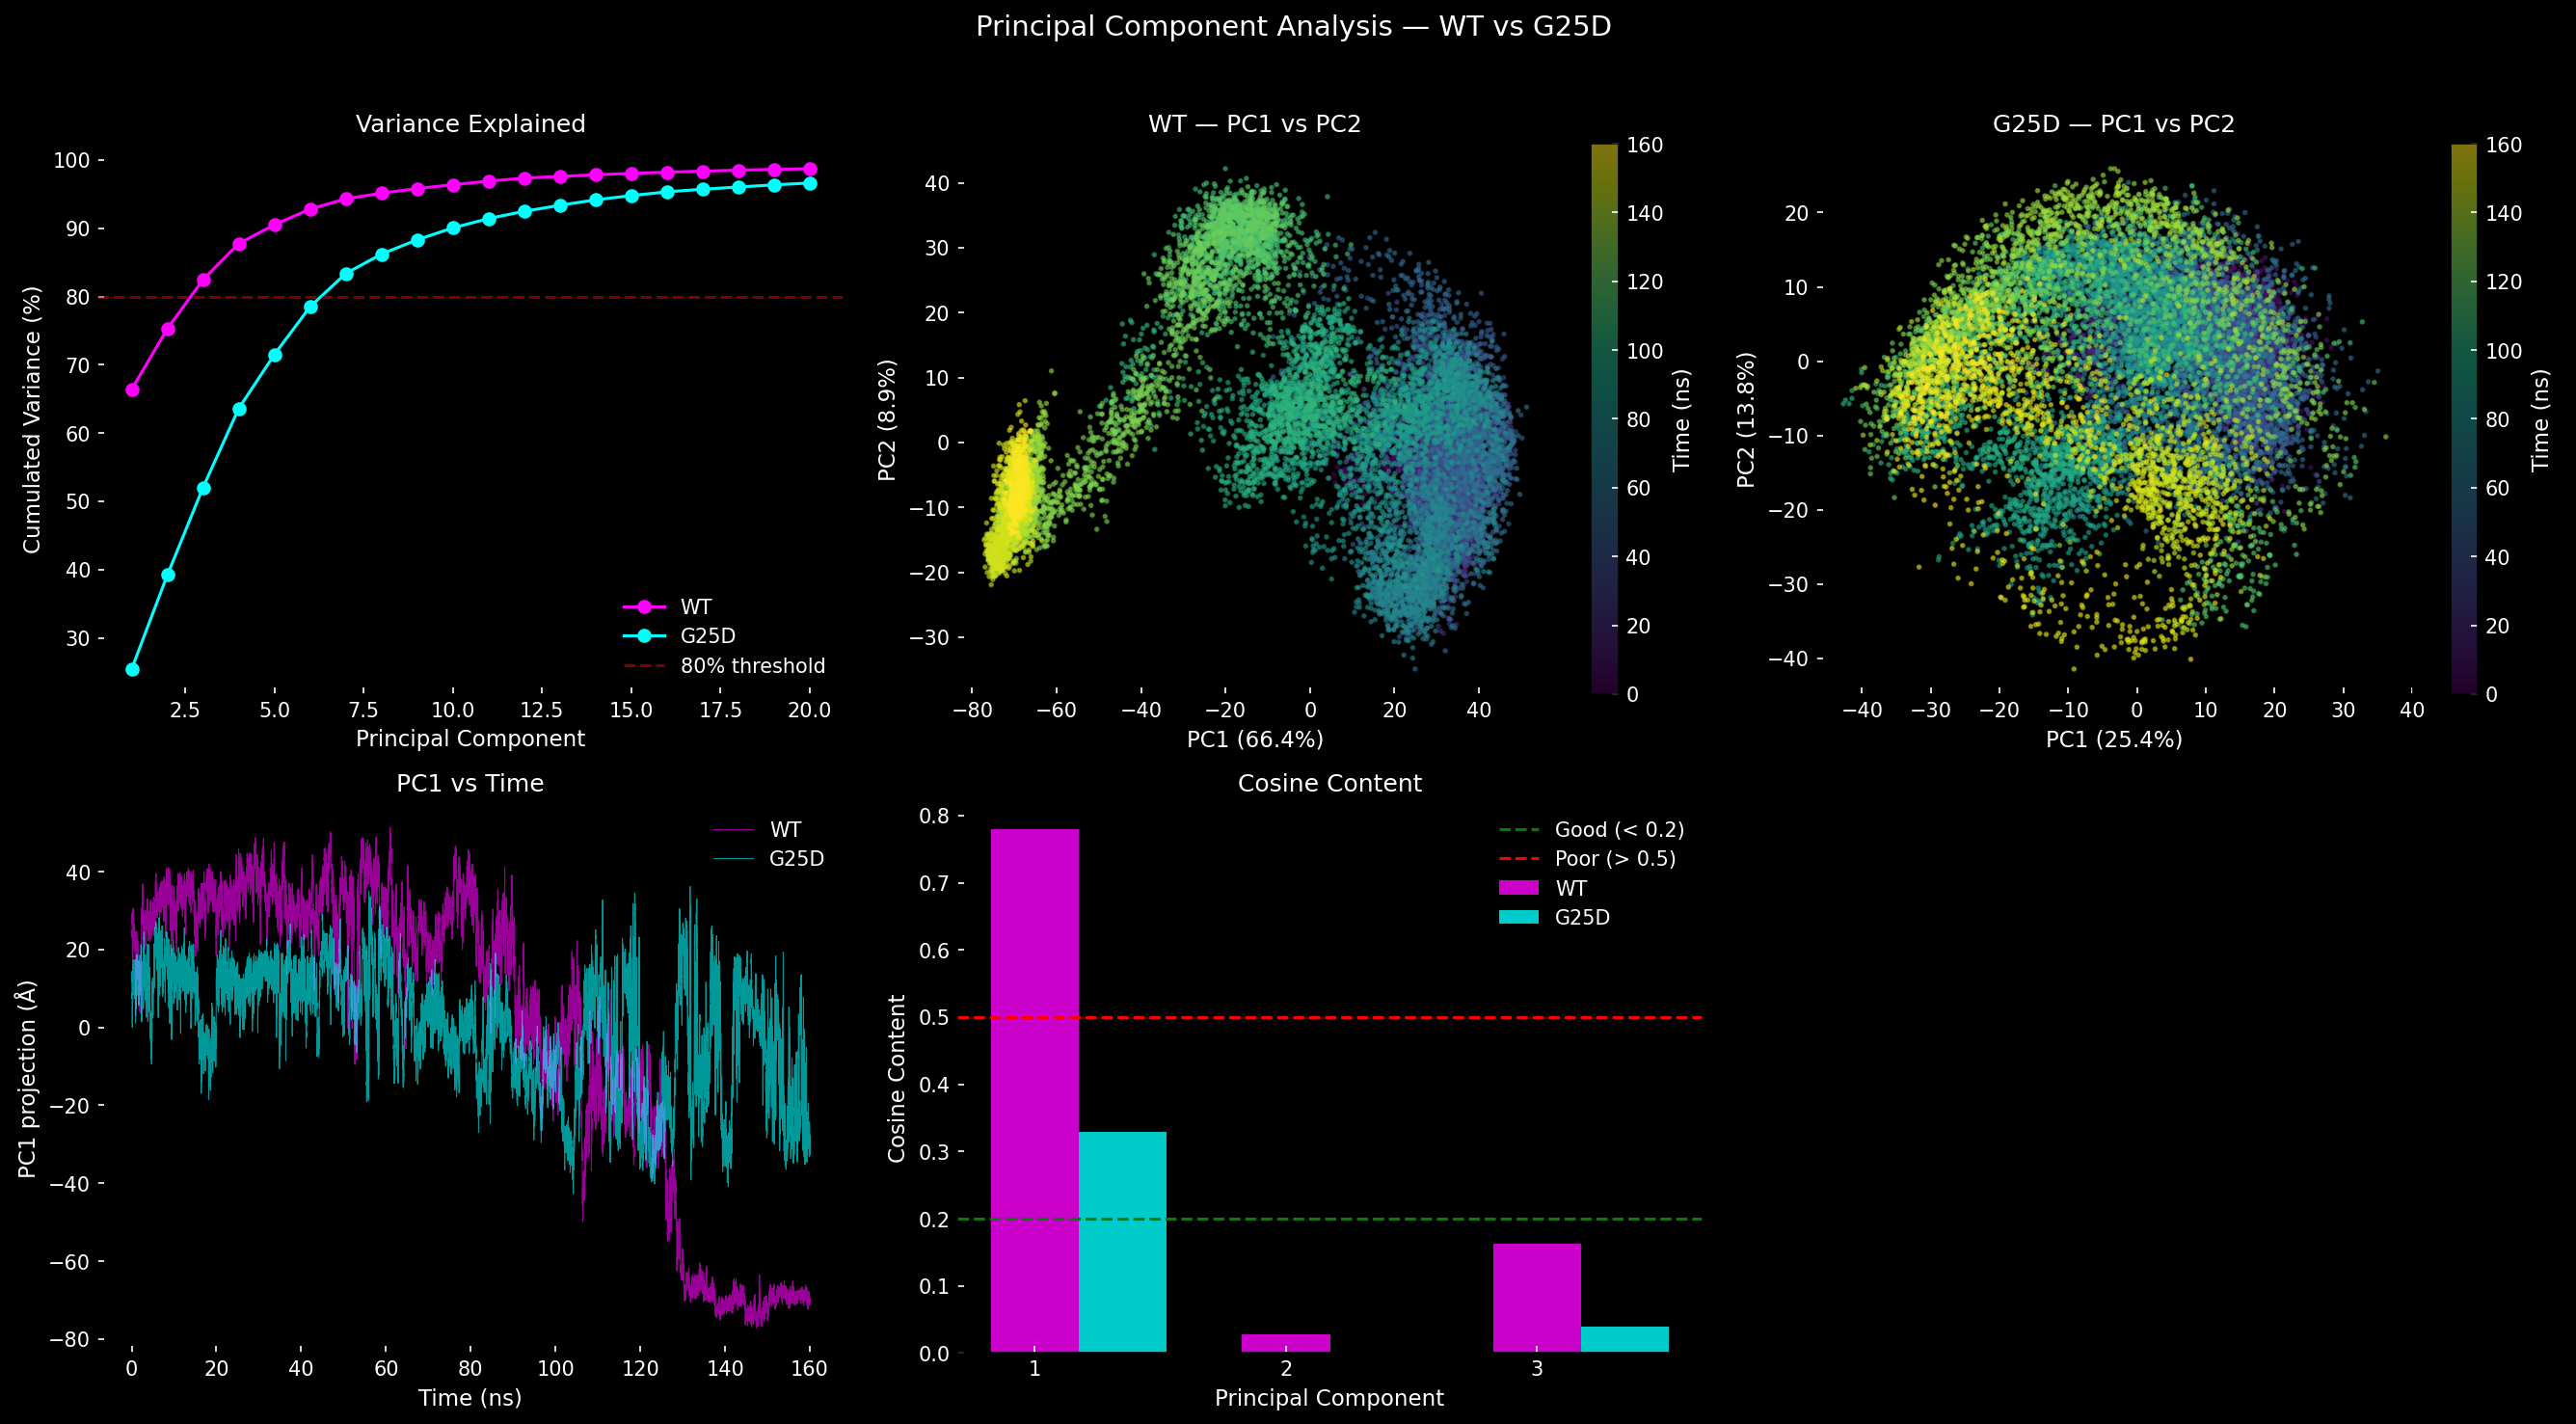

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Cumulated variance
axes[0, 0].plot(range(1, 21), cum_var_WT[:20]*100, "o-", color=colors["WT"], label="WT")
axes[0, 0].plot(range(1, 21), cum_var_G25D[:20]*100, "o-", color=colors["G25D"], label="G25D")
axes[0, 0].axhline(80, ls="--", color="red", alpha=0.5, label="80% threshold")
axes[0, 0].set_xlabel("Principal Component")
axes[0, 0].set_ylabel("Cumulated Variance (%)")
axes[0, 0].set_title("Variance Explained")
axes[0, 0].legend()

# PC1 vs PC2 — WT
sc1 = axes[0, 1].scatter(proj_WT[:, 0], proj_WT[:, 1], c=time_ns, cmap="viridis", s=3, alpha=0.5)
axes[0, 1].set_xlabel(f"PC1 ({pc_WT.results.variance[0]/pc_WT.results.variance.sum()*100:.1f}%)")
axes[0, 1].set_ylabel(f"PC2 ({pc_WT.results.variance[1]/pc_WT.results.variance.sum()*100:.1f}%)")
axes[0, 1].set_title("WT — PC1 vs PC2")
plt.colorbar(sc1, ax=axes[0, 1], label="Time (ns)")

# PC1 vs PC2 — G25D
sc2 = axes[0, 2].scatter(proj_G25D[:, 0], proj_G25D[:, 1], c=time_ns, cmap="viridis", s=3, alpha=0.5)
axes[0, 2].set_xlabel(f"PC1 ({pc_G25D.results.variance[0]/pc_G25D.results.variance.sum()*100:.1f}%)")
axes[0, 2].set_ylabel(f"PC2 ({pc_G25D.results.variance[1]/pc_G25D.results.variance.sum()*100:.1f}%)")
axes[0, 2].set_title("G25D — PC1 vs PC2")
plt.colorbar(sc2, ax=axes[0, 2], label="Time (ns)")

# PC1 vs Time
axes[1, 0].plot(time_ns, proj_WT[:, 0], lw=0.5, alpha=0.6, color=colors["WT"], label="WT")
axes[1, 0].plot(time_ns, proj_G25D[:, 0], lw=0.5, alpha=0.6, color=colors["G25D"], label="G25D")
axes[1, 0].set_xlabel("Time (ns)")
axes[1, 0].set_ylabel("PC1 projection (Å)")
axes[1, 0].set_title("PC1 vs Time")
axes[1, 0].legend()

# Cosine content
x = [1, 2, 3]
axes[1, 1].bar(x, cc_WT, width=0.35, label="WT", color=colors["WT"], alpha=0.8)
axes[1, 1].bar([i+0.35 for i in x], cc_G25D, width=0.35, label="G25D", color=colors["G25D"], alpha=0.8)
axes[1, 1].axhline(0.2, ls="--", color="green", label="Good (< 0.2)")
axes[1, 1].axhline(0.5, ls="--", color="red", label="Poor (> 0.5)")
axes[1, 1].set_xlabel("Principal Component")
axes[1, 1].set_ylabel("Cosine Content")
axes[1, 1].set_title("Cosine Content")
axes[1, 1].set_xticks(x)
axes[1, 1].legend()

axes[1, 2].axis('off')

plt.suptitle("Principal Component Analysis — WT vs G25D", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("../../images/09_pca_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 12a. Block averaging — Convergence Check

Performing block averaging for Rg...


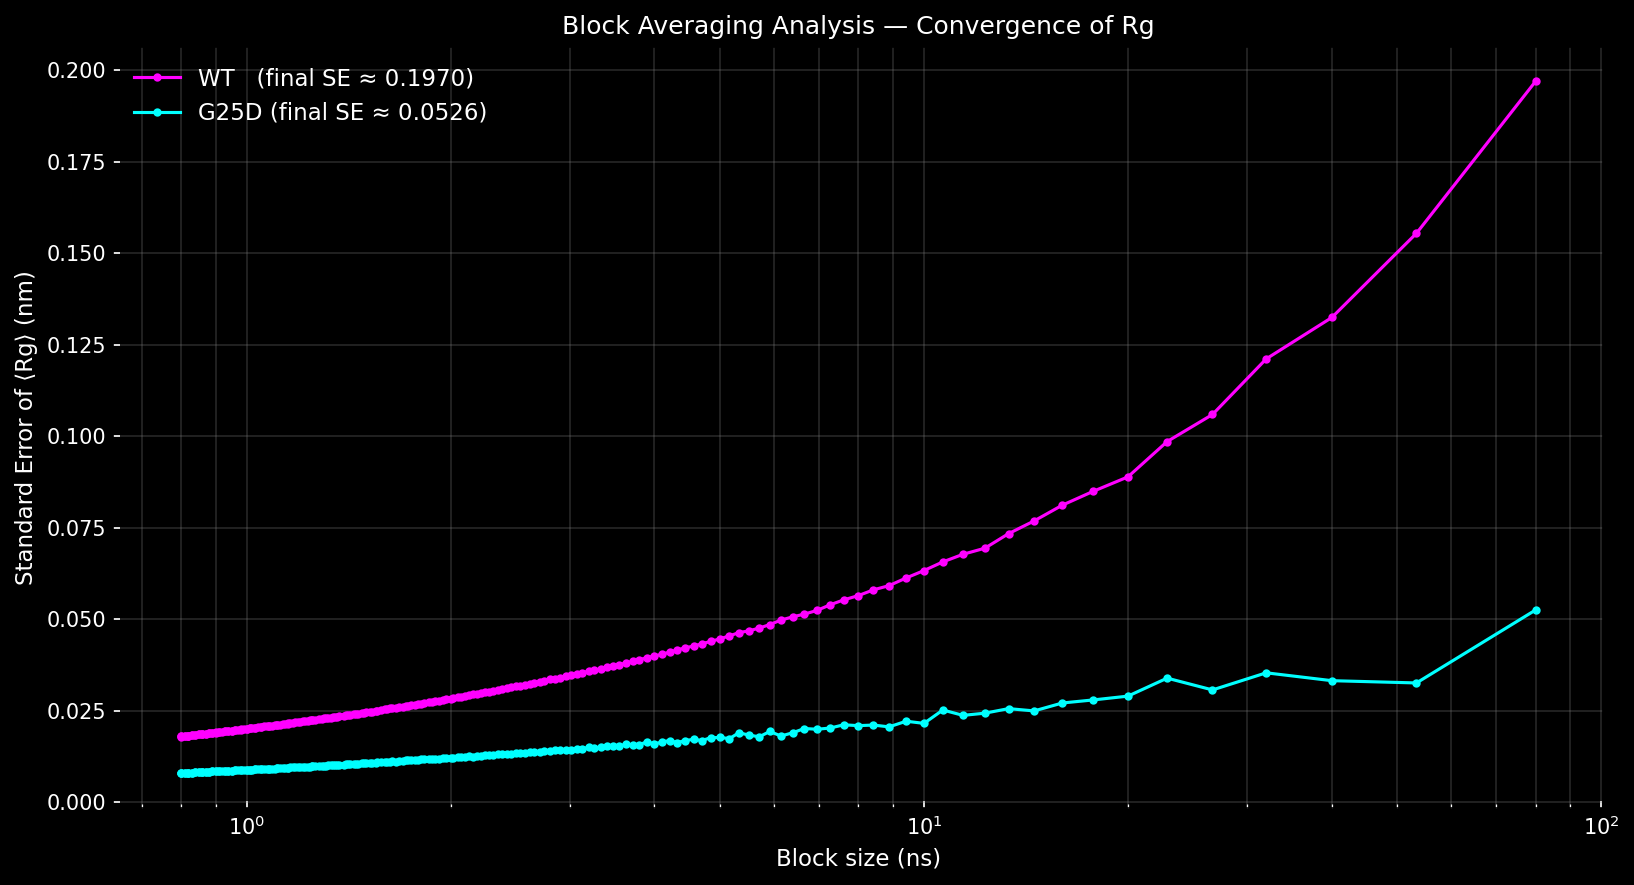

Final SE of mean Rg: WT = 0.1970 nm | G25D = 0.0526 nm


In [22]:
def block_average_se(x, max_blocks=200):
    x = np.asarray(x, dtype=float)
    N = len(x)
    sizes, ses = [], []
    for nb in range(max_blocks, 1, -1):
        bs = N // nb
        if bs < 2:
            continue
        means = x[:nb*bs].reshape(nb, bs).mean(axis=1)
        sizes.append(bs)
        ses.append(means.std(ddof=1) / np.sqrt(nb))
    return np.array(sizes), np.array(ses)


print("Performing block averaging for Rg...")

bsize_WT,   se_rg_WT   = block_average_se(rg_WT)
bsize_G25D, se_rg_G25D = block_average_se(rg_G25D)

bsize_ns_WT   = bsize_WT   * dt_ps / 1000
bsize_ns_G25D = bsize_G25D * dt_ps / 1000


fig, ax = plt.subplots(figsize=(11, 6))

ax.semilogx(bsize_ns_WT,   se_rg_WT,   "o-", color=colors["WT"], 
            markersize=3, lw=1.5, label=f"WT   (final SE ≈ {se_rg_WT[-1]:.4f})")
ax.semilogx(bsize_ns_G25D, se_rg_G25D, "o-", color=colors["G25D"], 
            markersize=3, lw=1.5, label=f"G25D (final SE ≈ {se_rg_G25D[-1]:.4f})")

ax.set_xlabel("Block size (ns)")
ax.set_ylabel("Standard Error of ⟨Rg⟩ (nm)")
ax.set_title("Block Averaging Analysis — Convergence of Rg")
ax.legend(fontsize=11)
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.savefig("../../images/11a_block_averaging_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Final SE of mean Rg: WT = {se_rg_WT[-1]:.4f} nm | G25D = {se_rg_G25D[-1]:.4f} nm")

## 12b. Half trajectory KS-Test — Convergence Check

/tmp/ipykernel_27156/3778598905.py:46: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
/tmp/ipykernel_27156/3778598905.py:47: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("../../images/11b_ks_test_comparison.png", dpi=300, bbox_inches="tight")
/home/sergey_ilin/anaconda3/envs/ml-hw5/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


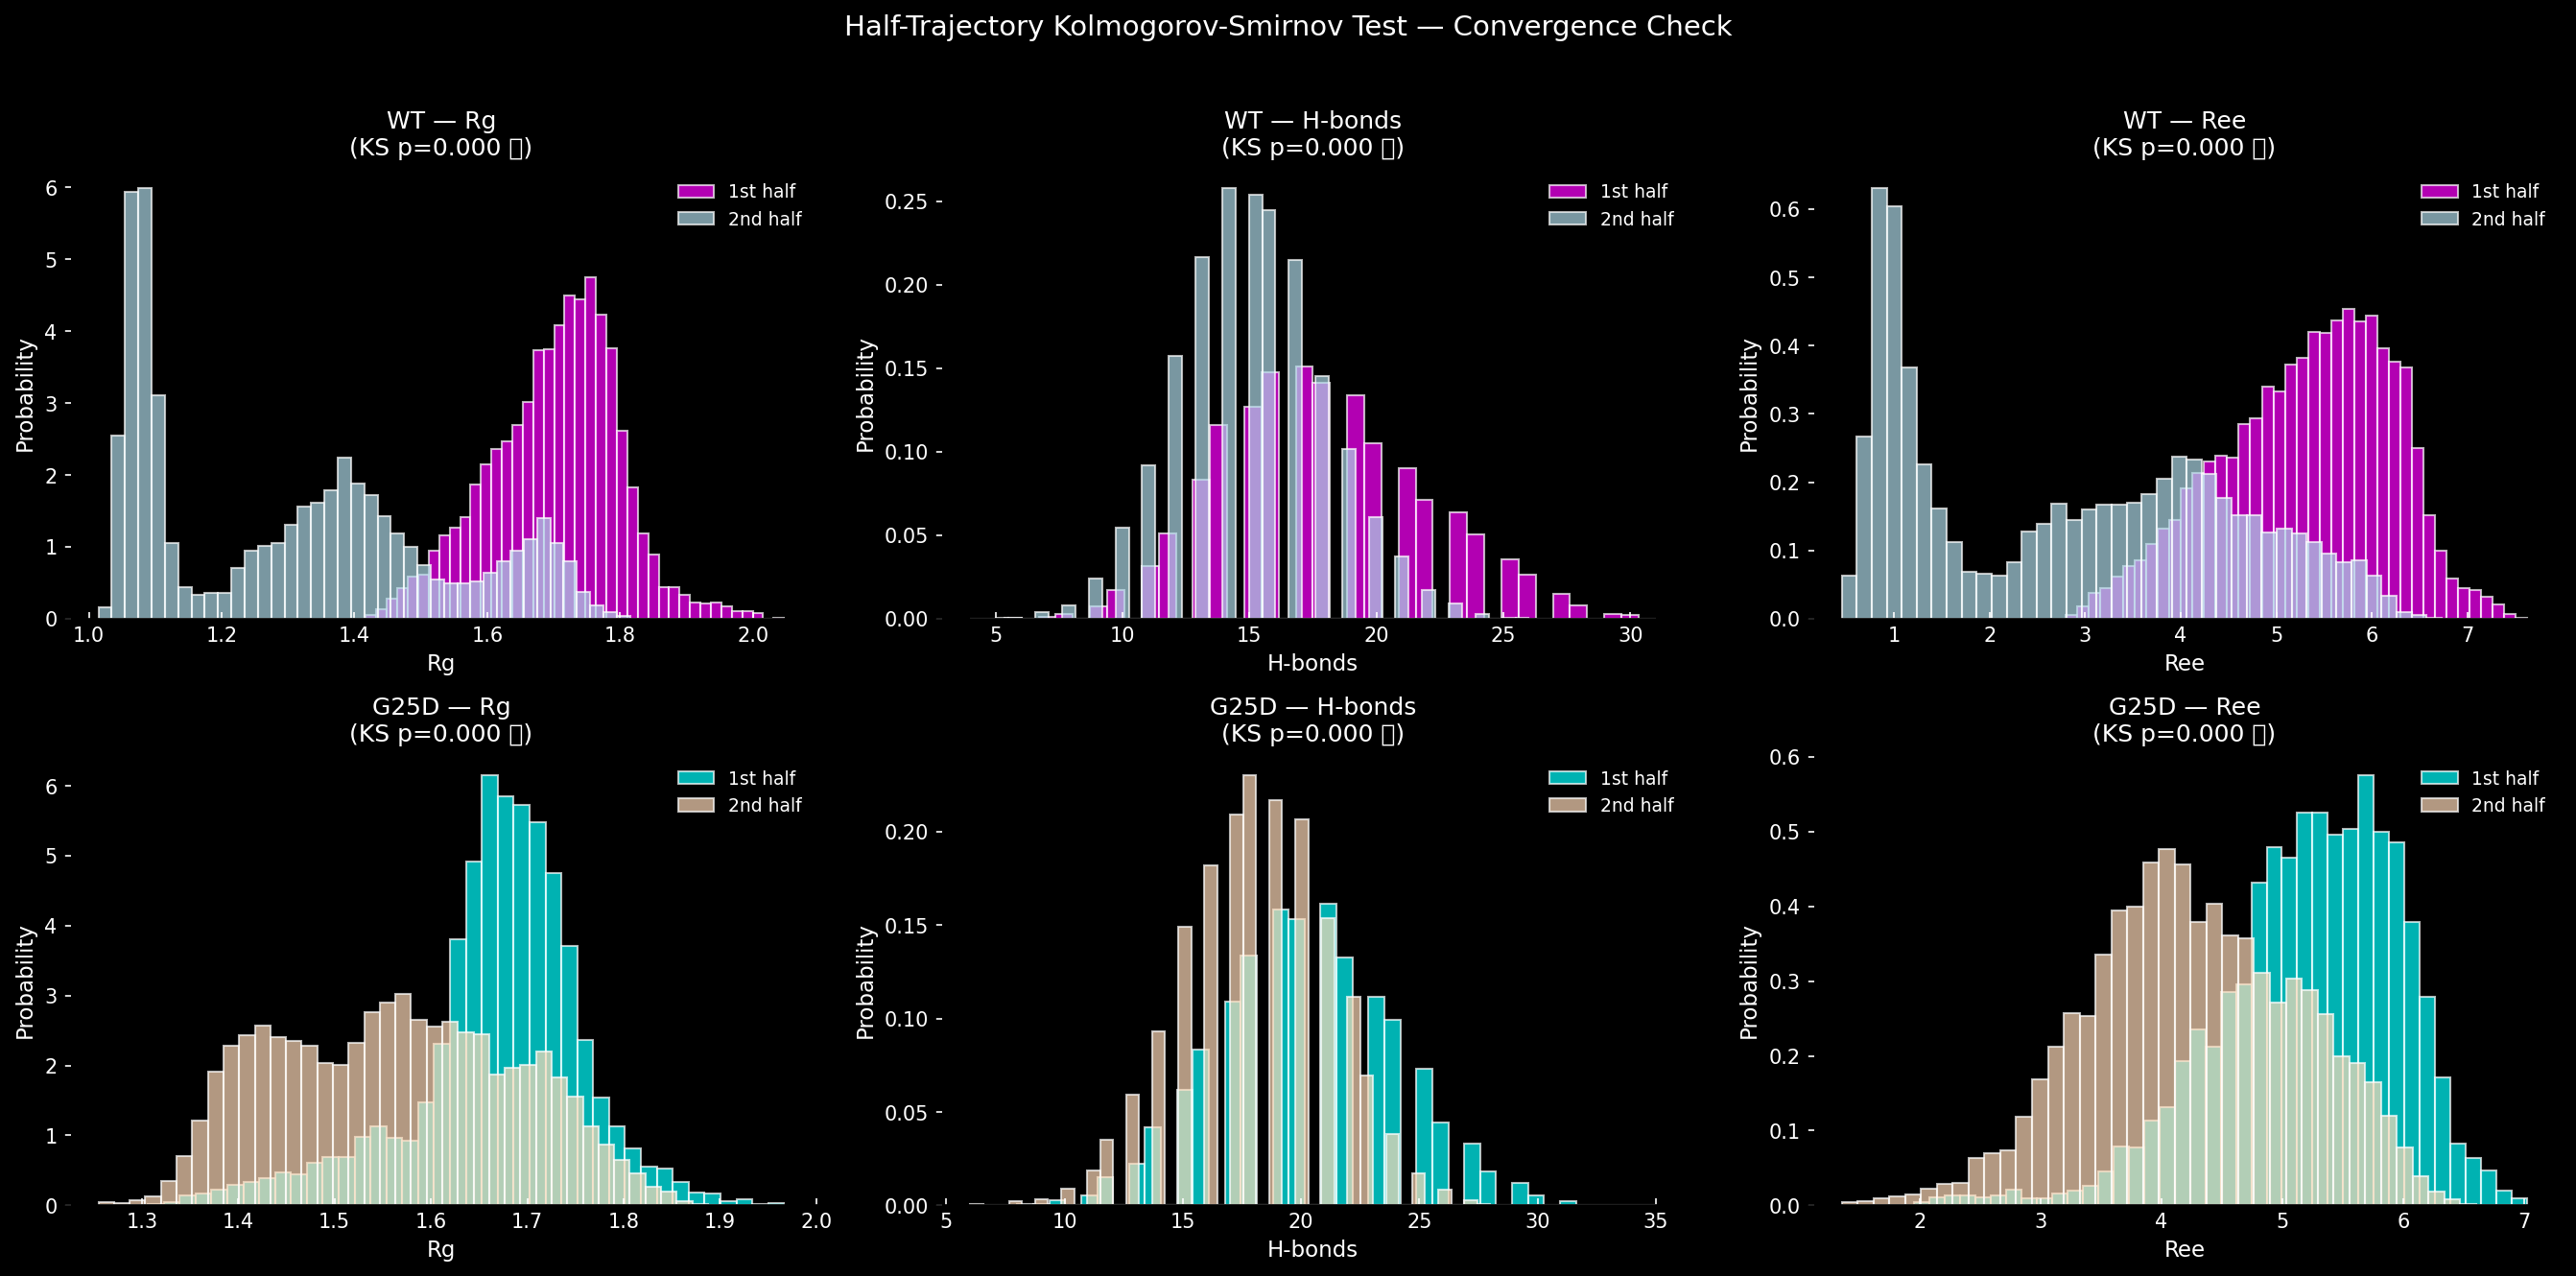

=== KS TEST RESULTS (1st vs 2nd half) ===
Property     WT D     WT p     WT   G25D D   G25D p   G25D
Rg           0.7770   0.0000   ❌     0.4534   0.0000   ❌
H-bonds      0.3054   0.0000   ❌     0.2472   0.0000   ❌
Ree          0.6267   0.0000   ❌     0.4638   0.0000   ❌


In [23]:
half = n_frames // 2

tests = [
    ("Rg", rg_WT, rg_G25D),
    ("H-bonds", n_hb_WT.astype(float), n_hb_G25D.astype(float)),
    ("Ree", ree_WT, ree_G25D),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
results_list = []

for i, (name, data_WT, data_G25D) in enumerate(tests):
    # KS test WT
    ks_WT, p_WT = stats.ks_2samp(data_WT[:half], data_WT[half:])
    status_WT = "✅" if p_WT > 0.05 else "❌"
    
    # KS test G25D
    ks_G25D, p_G25D = stats.ks_2samp(data_G25D[:half], data_G25D[half:])
    status_G25D = "✅" if p_G25D > 0.05 else "❌"
    
    results_list.append((name, ks_WT, p_WT, status_WT, ks_G25D, p_G25D, status_G25D))
    
    # Plot WT
    ax = axes[0, i]
    ax.hist(data_WT[:half], bins=40, density=True, alpha=0.7, 
            color=colors["WT"], label="1st half", edgecolor="white")
    ax.hist(data_WT[half:], bins=40, density=True, alpha=0.7, 
            color="lightblue", label="2nd half", edgecolor="white")
    ax.set_title(f"WT — {name}\n(KS p={p_WT:.3f} {status_WT})")
    ax.set_xlabel(name)
    ax.set_ylabel("Probability")
    ax.legend(fontsize=9)
    
    # Plot G25D
    ax = axes[1, i]
    ax.hist(data_G25D[:half], bins=40, density=True, alpha=0.7, 
            color=colors["G25D"], label="1st half", edgecolor="white")
    ax.hist(data_G25D[half:], bins=40, density=True, alpha=0.7, 
            color="peachpuff", label="2nd half", edgecolor="white")
    ax.set_title(f"G25D — {name}\n(KS p={p_G25D:.3f} {status_G25D})")
    ax.set_xlabel(name)
    ax.set_ylabel("Probability")
    ax.legend(fontsize=9)

plt.suptitle("Half-Trajectory Kolmogorov-Smirnov Test — Convergence Check", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("../../images/11b_ks_test_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# Summary table
print("=== KS TEST RESULTS (1st vs 2nd half) ===")
print(f"{'Property':<12} {'WT D':<8} {'WT p':<8} {'WT':<4} {'G25D D':<8} {'G25D p':<8} {'G25D':<4}")
for name, ks_WT, p_WT, st_WT, ks_G25D, p_G25D, st_G25D in results_list:
    print(f"{name:<12} {ks_WT:.4f}   {p_WT:.4f}   {st_WT}     {ks_G25D:.4f}   {p_G25D:.4f}   {st_G25D}")

## 12c. Autocorrelation time

Computing autocorrelation for Rg...
τ_int(WT) ≈ 45.2 ns | N_eff ≈ 4
τ_int(G25D) ≈ 10.2 ns | N_eff ≈ 16


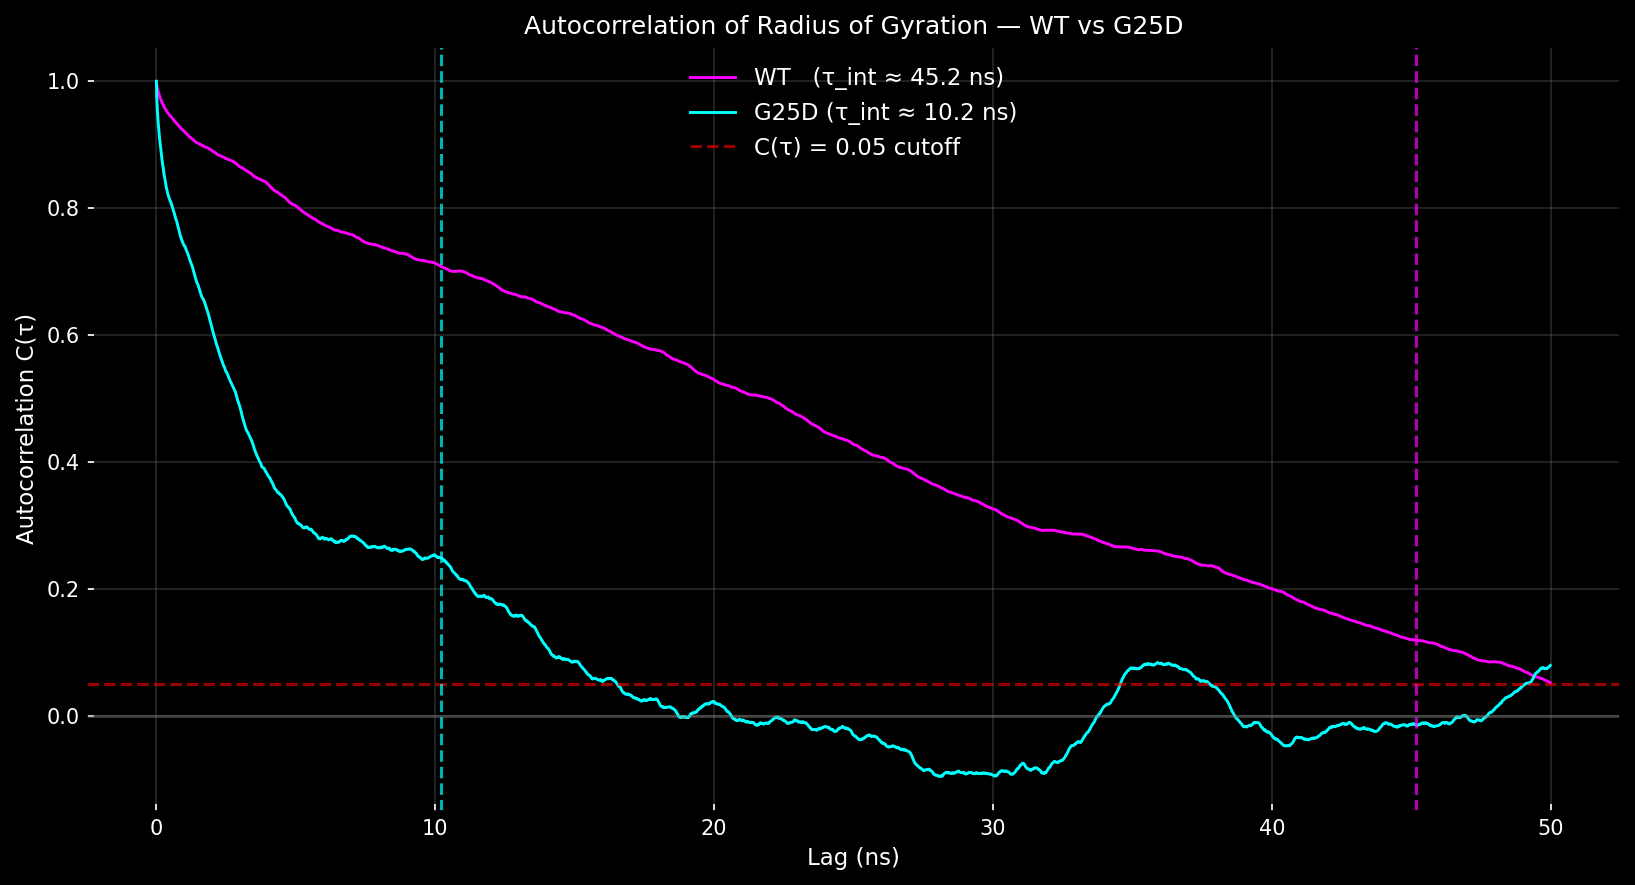

In [24]:
def autocorrelation(x):
    x = x - x.mean()
    result = correlate(x, x, mode="full")
    result = result[len(x)-1:]
    return result / result[0]

def compute_tau(x, dt_ps, name):
    ac = autocorrelation(x)
    cutoff_idx = np.argmax(ac < 0.05)
    if cutoff_idx == 0:
        cutoff_idx = len(ac) // 2
    tau_int = 1 + 2 * np.sum(ac[1:cutoff_idx])
    tau_ns = tau_int * dt_ps / 1000
    N_eff = len(x) / max(tau_int, 1)
    print(f"τ_int({name}) ≈ {tau_ns:.1f} ns | N_eff ≈ {N_eff:.0f}")
    return ac, tau_ns


print("Computing autocorrelation for Rg...")

ac_WT,   tau_WT   = compute_tau(rg_WT,   dt_ps, "WT")
ac_G25D, tau_G25D = compute_tau(rg_G25D, dt_ps, "G25D")


# Plotting
max_lag_ns = min(total_ns / 2, 50)
max_lag = int(max_lag_ns * 1000 / dt_ps)
lag_ns = np.arange(max_lag) * dt_ps / 1000

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(lag_ns, ac_WT[:max_lag],   lw=1.4, color=colors["WT"],   
        label=f"WT   (τ_int ≈ {tau_WT:.1f} ns)")
ax.plot(lag_ns, ac_G25D[:max_lag], lw=1.4, color=colors["G25D"], 
        label=f"G25D (τ_int ≈ {tau_G25D:.1f} ns)")

ax.axhline(0, ls="-", color="gray", alpha=0.4)
ax.axhline(0.05, ls="--", color="red", alpha=0.6, label="C(τ) = 0.05 cutoff")
ax.axvline(tau_WT,   ls="--", color=colors["WT"],   alpha=0.7)
ax.axvline(tau_G25D, ls="--", color=colors["G25D"], alpha=0.7)

ax.set_xlabel("Lag (ns)")
ax.set_ylabel("Autocorrelation C(τ)")
ax.set_title("Autocorrelation of Radius of Gyration — WT vs G25D")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../../images/11c_autocorrelation_overlaid.png", dpi=300, bbox_inches="tight")
plt.show()

## 12d. Convergence summary table

In [25]:
def get_cv(se_values):
    if len(se_values) < 10:
        return 999
    last_q = se_values[int(0.75*len(se_values)):]
    return last_q.std() / last_q.mean() if len(last_q) > 1 else 999

cv_rg_WT   = get_cv(se_rg_WT)
cv_rg_G25D = get_cv(se_rg_G25D)

summary_data = {
    "Diagnostic": [
        "Block-avg SE plateau (CV < 0.1)",
        "KS Rg (p > 0.05)",
        "KS H-bonds (p > 0.05)",
        "PC1 cosine content (< 0.2)",
        "τ_int / T_total (< 0.1)",
        "N_eff (≥ 50)"
    ],
    "WT": [
        f"CV = {cv_rg_WT:.3f}",
        f"p = {results_list[0][2]:.4f}",
        f"p = {results_list[1][2]:.4f}",
        f"{cc_WT[0]:.3f}",
        f"{tau_WT / total_ns:.3f}",
        "4"
    ],
    "G25D": [
        f"CV = {cv_rg_G25D:.3f}",
        f"p = {results_list[0][5]:.4f}",
        f"p = {results_list[1][5]:.4f}",
        f"{cc_G25D[0]:.3f}",
        f"{tau_G25D / total_ns:.3f}",
        "16"
    ],
    "WT Pass?": [
        "✅" if cv_rg_WT < 0.1 else "❌",
        "✅" if results_list[0][2] > 0.05 else "❌",
        "✅" if results_list[1][2] > 0.05 else "❌",
        "✅" if cc_WT[0] < 0.2 else ("⚠️" if cc_WT[0] < 0.5 else "❌"),
        "✅" if (tau_WT / total_ns) < 0.1 else "❌",
        "❌"
    ],
    "G25D Pass?": [
        "✅" if cv_rg_G25D < 0.1 else "❌",
        "✅" if results_list[0][5] > 0.05 else "❌",
        "✅" if results_list[1][5] > 0.05 else "❌",
        "✅" if cc_G25D[0] < 0.2 else ("⚠️" if cc_G25D[0] < 0.5 else "❌"),
        "✅" if (tau_G25D / total_ns) < 0.1 else "❌",
        "❌"
    ]
}

summary = pd.DataFrame(summary_data)

print("\n" + "="*80)
print("               CONVERGENCE ASSESSMENT SUMMARY — WT vs G25D")
print("="*80)
print(summary.to_string(index=False))
print("="*80)


               CONVERGENCE ASSESSMENT SUMMARY — WT vs G25D
                     Diagnostic         WT       G25D WT Pass? G25D Pass?
Block-avg SE plateau (CV < 0.1) CV = 0.531 CV = 0.333        ❌          ❌
               KS Rg (p > 0.05) p = 0.0000 p = 0.0000        ❌          ❌
          KS H-bonds (p > 0.05) p = 0.0000 p = 0.0000        ❌          ❌
     PC1 cosine content (< 0.2)      0.780      0.330        ❌         ⚠️
        τ_int / T_total (< 0.1)      0.282      0.064        ❌          ✅
                   N_eff (≥ 50)          4         16        ❌          ❌


# 13. Multi-panel summary figure

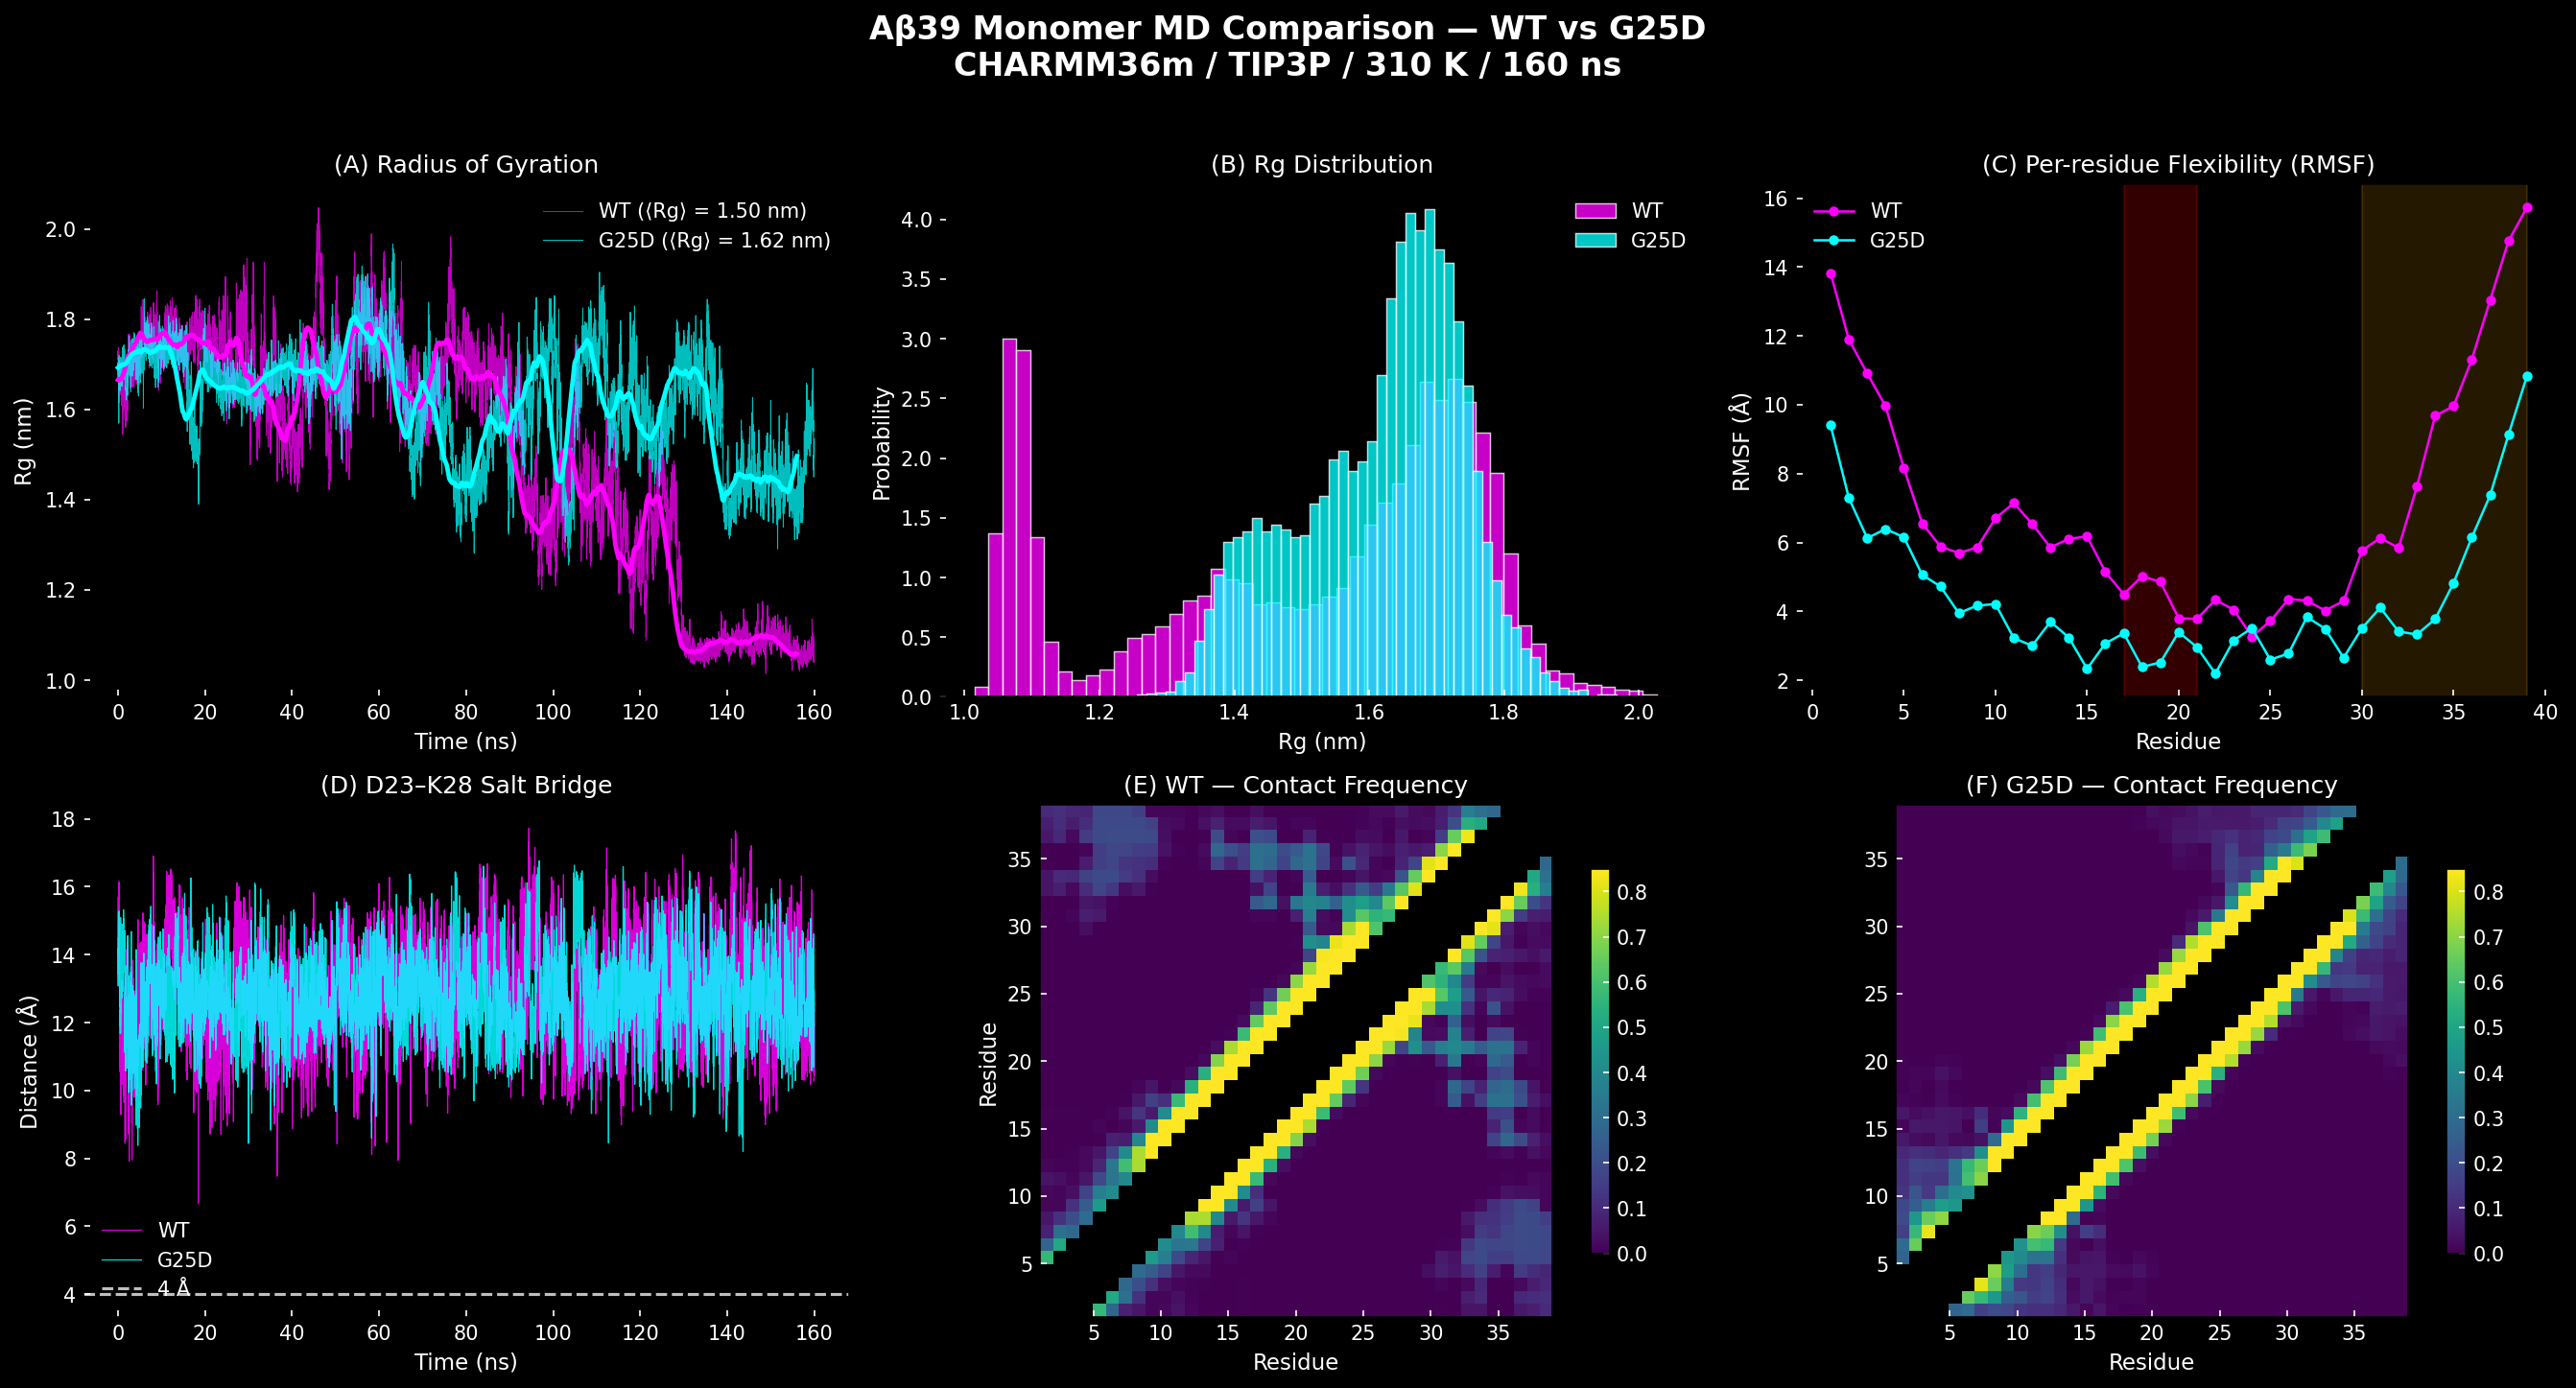

✅ Analysis completed. All figures saved.


In [26]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Aβ39 Monomer MD Comparison — WT vs G25D\n"
             "CHARMM36m / TIP3P / 310 K / 160 ns",
             fontsize=16, fontweight="bold", y=0.96)

# ROW 1
ax = axes[0, 0]
ax.plot(time_ns, rg_WT, lw=0.5, alpha=0.75, color=colors["WT"], 
        label=f"WT (⟨Rg⟩ = {rg_WT.mean():.2f} nm)")
ax.plot(time_ns, rg_G25D, lw=0.5, alpha=0.75, color=colors["G25D"], 
        label=f"G25D (⟨Rg⟩ = {rg_G25D.mean():.2f} nm)")
w = min(400, n_frames//6)
if w > 1:
    smooth_WT = np.convolve(rg_WT, np.ones(w)/w, mode='valid')
    smooth_G25D = np.convolve(rg_G25D, np.ones(w)/w, mode='valid')
    ax.plot(time_ns[:len(smooth_WT)], smooth_WT, lw=2.3, color=colors["WT"])
    ax.plot(time_ns[:len(smooth_G25D)], smooth_G25D, lw=2.3, color=colors["G25D"])
ax.set_xlabel("Time (ns)")
ax.set_ylabel("Rg (nm)")
ax.set_title("(A) Radius of Gyration")
ax.legend(fontsize=10)

ax = axes[0, 1]
ax.hist(rg_WT, bins=50, density=True, alpha=0.78, color=colors["WT"], 
        label="WT", edgecolor="white", linewidth=0.7)
ax.hist(rg_G25D, bins=50, density=True, alpha=0.78, color=colors["G25D"], 
        label="G25D", edgecolor="white", linewidth=0.7)
ax.set_xlabel("Rg (nm)")
ax.set_ylabel("Probability")
ax.set_title("(B) Rg Distribution")
ax.legend()

ax = axes[0, 2]
ax.plot(resids, rmsf_WT, "o-", color=colors["WT"], markersize=4, lw=1.2, label="WT")
ax.plot(resids, rmsf_G25D, "o-", color=colors["G25D"], markersize=4, lw=1.2, label="G25D")
ax.axvspan(17, 21, alpha=0.20, color="red")
ax.axvspan(30, 39, alpha=0.15, color="orange")
ax.set_xlabel("Residue")
ax.set_ylabel("RMSF (Å)")
ax.set_title("(C) Per-residue Flexibility (RMSF)")
ax.legend()

# ROW 2
ax = axes[1, 0]
ax.plot(time_ns, d_d23k28_WT, lw=0.6, alpha=0.85, color=colors["WT"], label="WT")
ax.plot(time_ns, d_d23k28_G25D, lw=0.6, alpha=0.85, color=colors["G25D"], label="G25D")
ax.axhline(4.0, ls="--", color="white", alpha=0.75, label="4 Å")
ax.set_xlabel("Time (ns)")
ax.set_ylabel("Distance (Å)")
ax.set_title("(D) D23–K28 Salt Bridge")
ax.legend(fontsize=10)

ax = axes[1, 1]
cf_p = contact_WT.copy()
cf_p[seq_mask] = np.nan
im = ax.imshow(cf_p, cmap="viridis", origin="lower",
               extent=[resids[0], resids[-1], resids[0], resids[-1]], vmin=0, vmax=0.85)
ax.set_title("(E) WT — Contact Frequency")
ax.set_xlabel("Residue")
ax.set_ylabel("Residue")
plt.colorbar(im, ax=ax, shrink=0.75)

ax = axes[1, 2]
cf_p = contact_G25D.copy()
cf_p[seq_mask] = np.nan
im = ax.imshow(cf_p, cmap="viridis", origin="lower",
               extent=[resids[0], resids[-1], resids[0], resids[-1]], vmin=0, vmax=0.85)
ax.set_title("(F) G25D — Contact Frequency")
ax.set_xlabel("Residue")
plt.colorbar(im, ax=ax, shrink=0.75)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("../../images/13_summary_comparison.png", dpi=650, bbox_inches="tight")
plt.savefig("../../images/13_summary_comparison.pdf", bbox_inches="tight")
plt.show()

print("✅ Analysis completed. All figures saved.")